 # GA Part Time Data Science Course: Final Project

This project works on this [Kaggle Dataset](https://www.kaggle.com/uciml/adult-census-income/home). The data is drawn from the US 1994 Census Bureau, and the prediction task is to identify persons earning more than $50K a year.

### Attributes and data types

* **age**: continuous. 
* **workclass**: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked. 
* **education**: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool. 
* **education-num**: continuous. 
* **marital-status**: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse. 
* **occupation**: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces. 
* **relationship**: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried. 
* **race**: Black, White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other. 
* **sex**: Female, Male. 
* **capital-gain**: continuous. 
* **capital-loss**: continuous. 
* **hours-per-week**: continuous. 
* **native-country**: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

## Getting Started

In this project, you will employ several supervised algorithms of your choice to accurately model individuals' income using data collected from the 1994 U.S. Census. You will then choose the best candidate algorithm from preliminary results and further optimize this algorithm to best model the data. Your goal with this implementation is to construct a model that accurately predicts whether an individual makes more than $50,000. This sort of task can arise in a non-profit setting, where organizations survive on donations.  Understanding an individual's income can help a non-profit better understand how large of a donation to request, or whether or not they should reach out to begin with.  While it can be difficult to determine an individual's general income bracket directly from public sources, we can (as we will see) infer this value from other publically available features. 

The dataset for this project originates from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Census+Income). The datset was donated by Ron Kohavi and Barry Becker, after being published in the article _"Scaling Up the Accuracy of Naive-Bayes Classifiers: A Decision-Tree Hybrid"_. You can find the article by Ron Kohavi [online](https://www.aaai.org/Papers/KDD/1996/KDD96-033.pdf). The data we investigate here consists of small changes to the original dataset, such as removing the `'fnlwgt'` feature and records with missing or ill-formatted entries.

----
## Exploring the Data
Run the code cell below to load necessary Python libraries and load the census data. Note that the last column from this dataset, `'income'`, will be our target label (whether an individual makes more than, or at most, $50,000 annually). All other columns are features about each individual in the census database.

In [1]:
# Import libraries necessary for this project
import numpy as np
import pandas as pd
from time import time
from IPython.display import display # Allows the use of display() for DataFrames

# Import supplementary visualization code visuals.py
import visuals as vs

# Pretty display for notebooks
%matplotlib inline

# Load the Census dataset
data = pd.read_csv("census.csv")

# Success - Display the first record
display(data.head(n=5))

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


In [2]:
data.drop_duplicates(inplace=True)

In [3]:
data=data.replace(['<=50K','>50K'],[0,1])

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 39240 entries, 0 to 45221
Data columns (total 14 columns):
age                39240 non-null int64
workclass          39240 non-null object
education_level    39240 non-null object
education-num      39240 non-null float64
marital-status     39240 non-null object
occupation         39240 non-null object
relationship       39240 non-null object
race               39240 non-null object
sex                39240 non-null object
capital-gain       39240 non-null float64
capital-loss       39240 non-null float64
hours-per-week     39240 non-null float64
native-country     39240 non-null object
income             39240 non-null int64
dtypes: float64(4), int64(2), object(8)
memory usage: 4.5+ MB


In [5]:
data.reset_index(drop=True, inplace=True)

### Age

/anaconda3/lib/python3.6/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


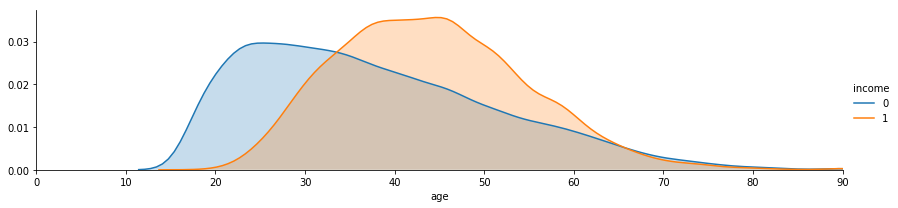

In [6]:
import seaborn as sns
facet = sns.FacetGrid(data, hue='income',aspect=4)
facet.map(sns.kdeplot,'age',shade= True)
facet.set(xlim=(0, data['age'].max()))
facet.add_legend()

In [7]:
data['age_grp'] = (data.age/5).astype(int)*5
data.head()

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,age_grp
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,0,35
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,0,50
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,0,35
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,0,50
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,0,25


/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:2: FutureWarning: Method .as_matrix will be removed in a future version. Use .values instead.
  


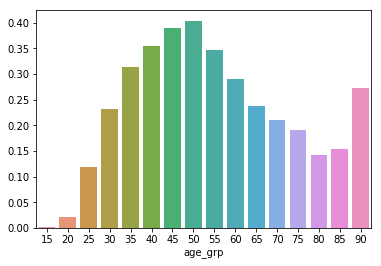

In [8]:
age_sub = data.groupby('age_grp').income.sum()/data.groupby('age_grp').income.count()
sns.barplot(x=age_sub.index,y=age_sub.as_matrix())

In [9]:
data.age_grp.replace(age_sub.index,age_sub.as_matrix(),inplace=True)
data.head()

/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:1: FutureWarning: Method .as_matrix will be removed in a future version. Use .values instead.
  """Entry point for launching an IPython kernel.


,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,age_grp
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,0,0.314302
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,0,0.403834
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,0,0.314302
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,0,0.403834
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,0,0.119467


In [10]:
data.drop('age',axis=1,inplace=True)

In [11]:
data[data.age_grp>0.2].income.count()/data.income.count()

0.7253822629969419

In [12]:
data[data.age_grp>0.2].income.sum()/data.income.count()

0.23588175331294597

In [13]:
data.income.sum()/data.income.count()

0.25420489296636084

### Workclass

In [14]:
for i in data.workclass.unique():
    print(i)
    print(data[data.workclass==i].occupation.unique())
    print(len(data[data.workclass==i].occupation.unique()))

 State-gov
[' Adm-clerical' ' Prof-specialty' ' Other-service' ' Craft-repair'
 ' Protective-serv' ' Machine-op-inspct' ' Transport-moving'
 ' Exec-managerial' ' Tech-support' ' Sales' ' Farming-fishing'
 ' Handlers-cleaners']
12
 Self-emp-not-inc
[' Exec-managerial' ' Farming-fishing' ' Prof-specialty' ' Sales'
 ' Other-service' ' Craft-repair' ' Handlers-cleaners' ' Tech-support'
 ' Transport-moving' ' Adm-clerical' ' Machine-op-inspct'
 ' Protective-serv']
12
 Private
[' Handlers-cleaners' ' Prof-specialty' ' Exec-managerial'
 ' Other-service' ' Adm-clerical' ' Sales' ' Transport-moving'
 ' Machine-op-inspct' ' Tech-support' ' Craft-repair' ' Farming-fishing'
 ' Protective-serv' ' Priv-house-serv']
13
 Federal-gov
[' Farming-fishing' ' Adm-clerical' ' Prof-specialty' ' Exec-managerial'
 ' Other-service' ' Tech-support' ' Sales' ' Armed-Forces' ' Craft-repair'
 ' Handlers-cleaners' ' Transport-moving' ' Protective-serv'
 ' Machine-op-inspct']
13
 Local-gov
[' Tech-support' ' Protecti

In [15]:
occ_dict = {}
for occ in data.occupation.unique():
    occ_dict[occ] = []
    for workclass in data.workclass.unique():
        if workclass in data[data.occupation==occ].workclass.unique():
            occ_dict[occ].append(data[(data.occupation==occ)&(data.workclass==workclass)].income.sum()/data[(data.occupation==occ)&(data.workclass==workclass)].income.count())
        else:
            occ_dict[occ].append(0)
occ_dict

{' Adm-clerical': [0.11666666666666667,
  0.2608695652173913,
  0.1275465013286094,
  0.3199152542372881,
  0.12776412776412777,
  0.29545454545454547,
  0.0],
 ' Exec-managerial': [0.44,
  0.3664259927797834,
  0.45975975975975975,
  0.5116279069767442,
  0.4613003095975232,
  0.6192982456140351,
  0.0],
 ' Handlers-cleaners': [0.05555555555555555,
  0.14285714285714285,
  0.06704980842911877,
  0.08571428571428572,
  0.171875,
  0.16666666666666666,
  0.5],
 ' Prof-specialty': [0.40033783783783783,
  0.5459459459459459,
  0.4349760438056126,
  0.5414847161572053,
  0.36799184505606525,
  0.7637130801687764,
  0],
 ' Other-service': [0.047872340425531915,
  0.072992700729927,
  0.03937702027622686,
  0.09259259259259259,
  0.058823529411764705,
  0.23809523809523808,
  0.0],
 ' Sales': [0.21052631578947367,
  0.33212996389891697,
  0.2417552466612156,
  0.29411764705882354,
  0.1875,
  0.5468354430379747,
  0.0],
 ' Transport-moving': [0.1206896551724138,
  0.22727272727272727,
  0.22

In [16]:
occ_data = pd.DataFrame(data=occ_dict)

In [17]:
occ_data.head()

,Adm-clerical,Exec-managerial,Handlers-cleaners,Prof-specialty,Other-service,Sales,Transport-moving,Farming-fishing,Machine-op-inspct,Tech-support,Craft-repair,Protective-serv,Armed-Forces,Priv-house-serv
0,0.116667,0.440000,0.055556,0.400338,0.047872,0.210526,0.120690,0.125000,0.315789,0.141176,0.264368,0.275449,0.000000,0.000000
1,0.260870,0.366426,0.142857,0.545946,0.072993,0.332130,0.227273,0.153968,0.206897,0.333333,0.185185,0.285714,0.000000,0.000000
2,0.127547,0.459760,0.067050,0.434976,0.039377,0.241755,0.220598,0.068254,0.123591,0.283510,0.231111,0.152249,0.000000,0.013043
3,0.319915,0.511628,0.085714,0.541485,0.092593,0.294118,0.277778,0.222222,0.157895,0.372340,0.352273,0.478261,0.285714,0.000000
4,0.127764,0.461300,0.171875,0.367992,0.058824,0.187500,0.152318,0.047619,0.181818,0.362069,0.271357,0.416076,0.000000,0.000000


In [18]:
occ_data['workclass'] = data.workclass.unique()
occ_data.set_index('workclass',drop=True,inplace=True)
occ_data.head()

,Adm-clerical,Exec-managerial,Handlers-cleaners,Prof-specialty,Other-service,Sales,Transport-moving,Farming-fishing,Machine-op-inspct,Tech-support,Craft-repair,Protective-serv,Armed-Forces,Priv-house-serv
workclass,,,,,,,,,,,,,,
State-gov,0.116667,0.440000,0.055556,0.400338,0.047872,0.210526,0.120690,0.125000,0.315789,0.141176,0.264368,0.275449,0.000000,0.000000
Self-emp-not-inc,0.260870,0.366426,0.142857,0.545946,0.072993,0.332130,0.227273,0.153968,0.206897,0.333333,0.185185,0.285714,0.000000,0.000000
Private,0.127547,0.459760,0.067050,0.434976,0.039377,0.241755,0.220598,0.068254,0.123591,0.283510,0.231111,0.152249,0.000000,0.013043
Federal-gov,0.319915,0.511628,0.085714,0.541485,0.092593,0.294118,0.277778,0.222222,0.157895,0.372340,0.352273,0.478261,0.285714,0.000000
Local-gov,0.127764,0.461300,0.171875,0.367992,0.058824,0.187500,0.152318,0.047619,0.181818,0.362069,0.271357,0.416076,0.000000,0.000000


In [19]:
occ_data[' Adm-clerical'].loc[' State-gov']

0.11666666666666667

In [20]:
data[(data.occupation==' Adm-clerical')&(data.workclass==' Private')].index

Int64Index([   12,    35,    40,    54,    61,    62,    70,   117,   118,
              127,
            ...
            39150, 39157, 39168, 39170, 39187, 39189, 39214, 39231, 39233,
            39238],
           dtype='int64', length=3387)

In [21]:
data['Profession'] = 0
for occ in data.occupation.unique():
    for workclass in data.workclass.unique():
        i = data[(data.occupation==occ)&(data.workclass==workclass)].index
        data.Profession.iloc[i] = occ_data[occ].loc[workclass]
data.head()

/anaconda3/lib/python3.6/site-packages/pandas/core/indexing.py:189: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  self._setitem_with_indexer(indexer, value)


,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,age_grp,Profession
0,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,0,0.314302,0.116667
1,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,0,0.403834,0.366426
2,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,0,0.314302,0.067050
3,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,0,0.403834,0.067050
4,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,0,0.119467,0.434976


In [22]:
data.drop(['workclass','occupation'],axis=1,inplace=True)

In [23]:
data.head()

,education_level,education-num,marital-status,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,age_grp,Profession
0,Bachelors,13.0,Never-married,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,0,0.314302,0.116667
1,Bachelors,13.0,Married-civ-spouse,Husband,White,Male,0.0,0.0,13.0,United-States,0,0.403834,0.366426
2,HS-grad,9.0,Divorced,Not-in-family,White,Male,0.0,0.0,40.0,United-States,0,0.314302,0.067050
3,11th,7.0,Married-civ-spouse,Husband,Black,Male,0.0,0.0,40.0,United-States,0,0.403834,0.067050
4,Bachelors,13.0,Married-civ-spouse,Wife,Black,Female,0.0,0.0,40.0,Cuba,0,0.119467,0.434976


In [24]:
data[(data.Profession>0.1) | (data.age_grp>0.1)].income.sum()/data.income.sum()

0.9988972431077694

### Education

/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:2: FutureWarning: Method .as_matrix will be removed in a future version. Use .values instead.
  


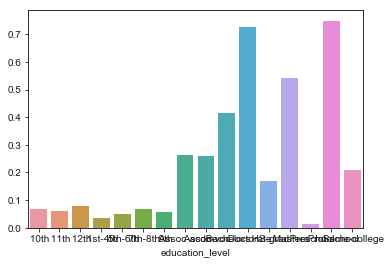

In [25]:
ed = data.groupby('education_level').income.sum()/data.groupby('education_level').income.count()
sns.barplot(x=data.groupby('education_level').sum().index,y=ed.as_matrix())
sns.set(rc={'figure.figsize':(30,30)})

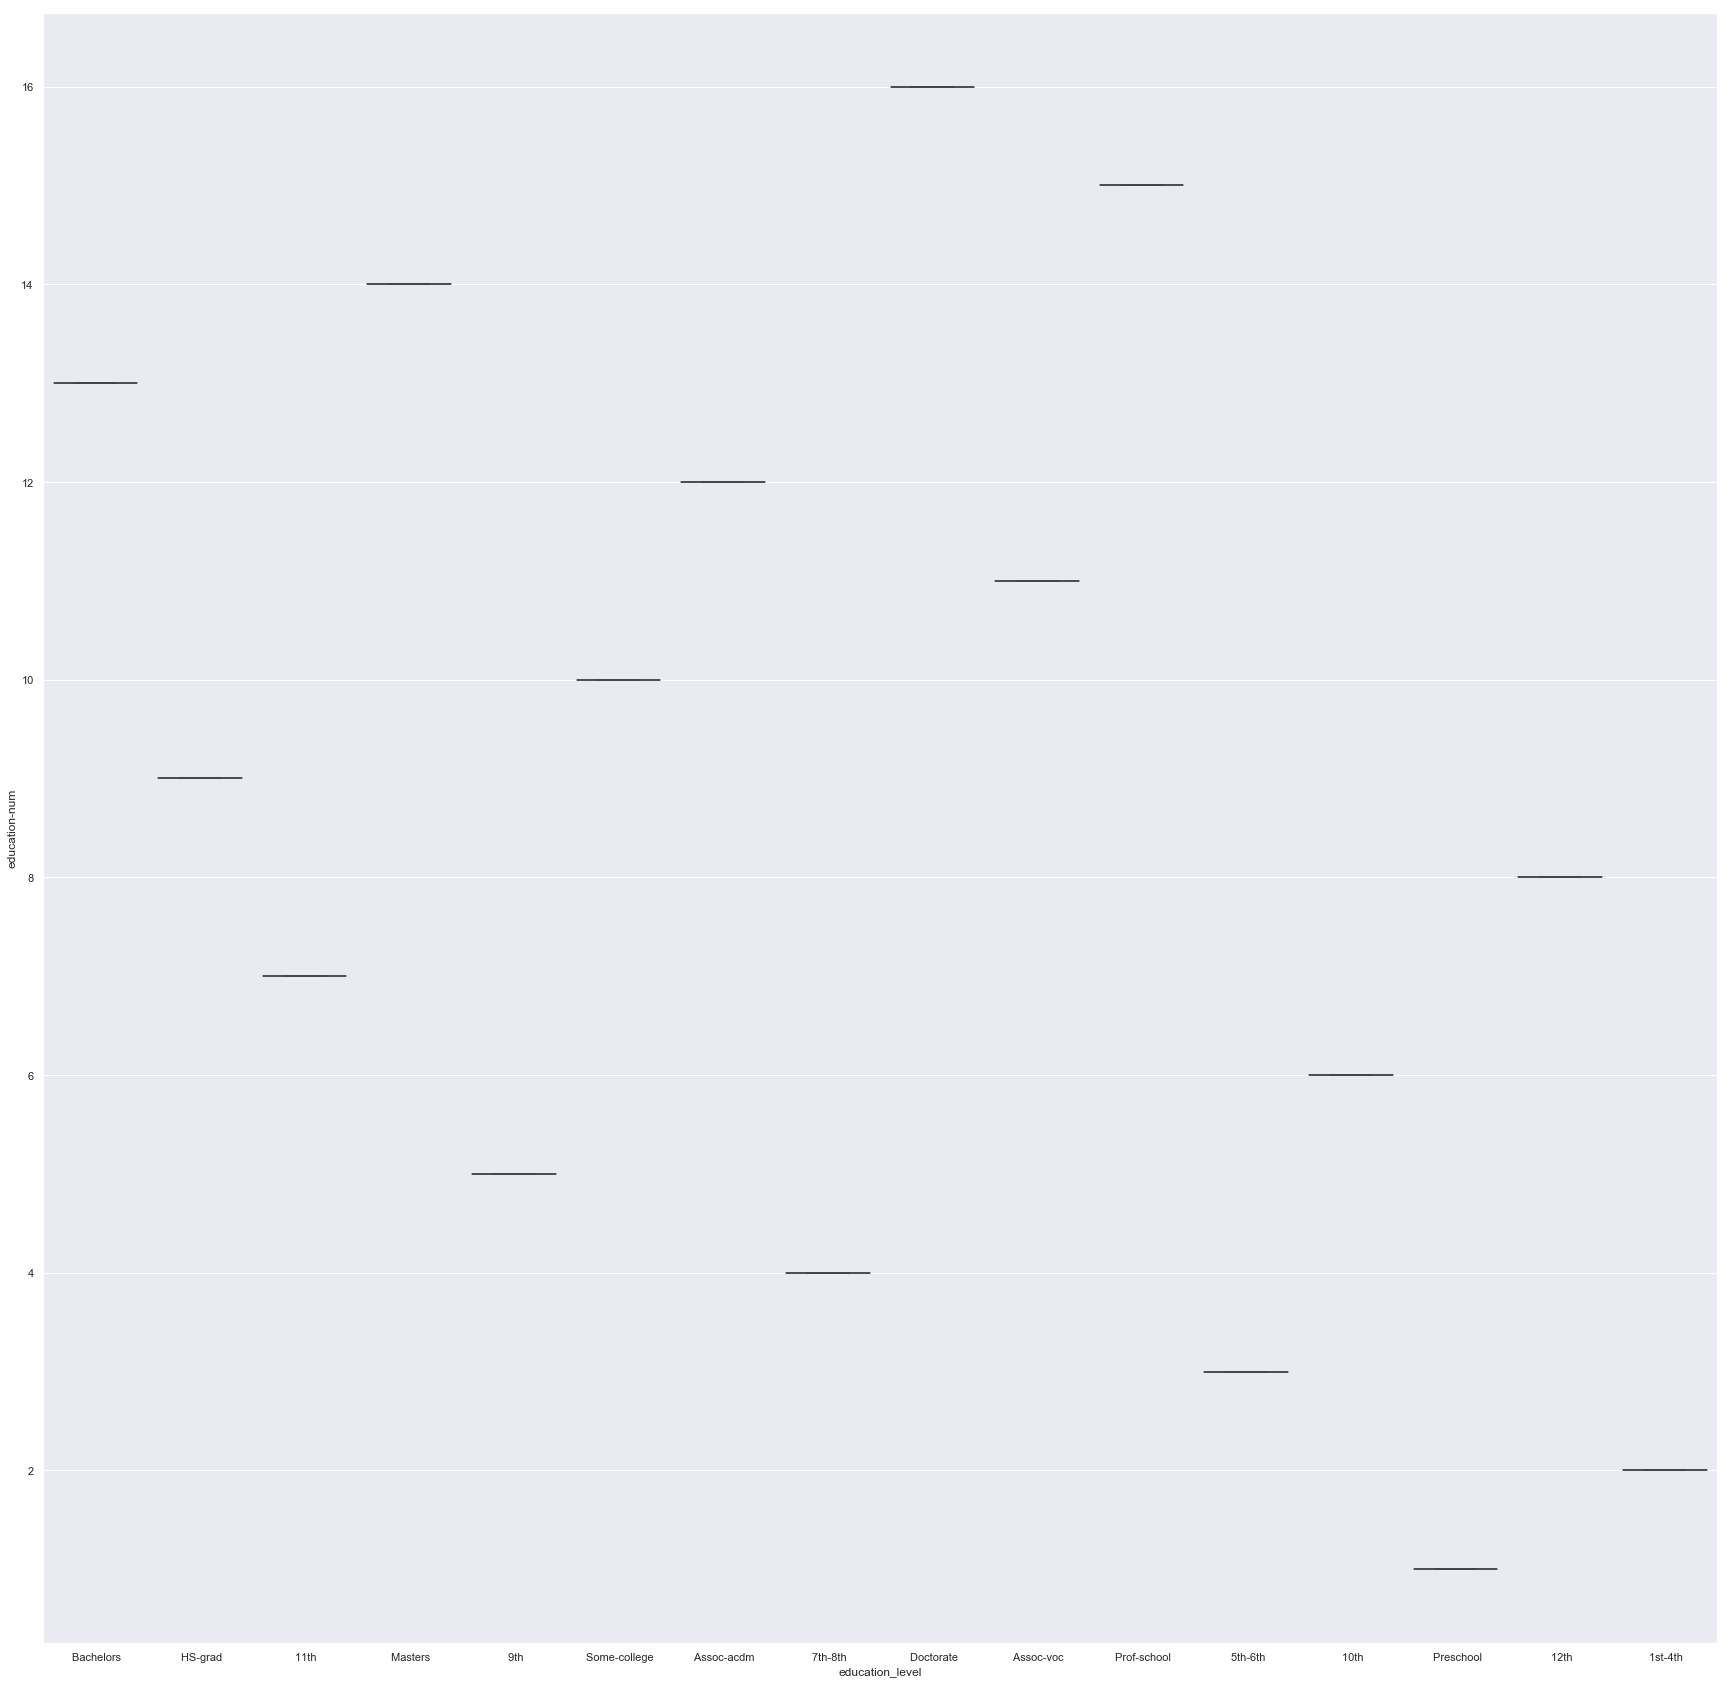

In [26]:
sns.boxplot(x=data.education_level,y=data['education-num'])

In [27]:
ed2 = data.groupby('education_level')['education-num'].mean().as_matrix()
ed2

/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:1: FutureWarning: Method .as_matrix will be removed in a future version. Use .values instead.
  """Entry point for launching an IPython kernel.


array([ 6.,  7.,  8.,  2.,  3.,  4.,  5., 12., 11., 13., 16.,  9., 14.,
        1., 15., 10.])

In [28]:
np.corrcoef(ed.as_matrix(),ed2)

/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:1: FutureWarning: Method .as_matrix will be removed in a future version. Use .values instead.
  """Entry point for launching an IPython kernel.


array([[1.       , 0.8969869],
       [0.8969869, 1.       ]])

In [29]:
data['education-num'].replace(ed2,ed.as_matrix(),inplace=True)
data.head()

/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:1: FutureWarning: Method .as_matrix will be removed in a future version. Use .values instead.
  """Entry point for launching an IPython kernel.


,education_level,education-num,marital-status,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,age_grp,Profession
0,Bachelors,0.415823,Never-married,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,0,0.314302,0.116667
1,Bachelors,0.415823,Married-civ-spouse,Husband,White,Male,0.0,0.0,13.0,United-States,0,0.403834,0.366426
2,HS-grad,0.170457,Divorced,Not-in-family,White,Male,0.0,0.0,40.0,United-States,0,0.314302,0.067050
3,11th,0.061885,Married-civ-spouse,Husband,Black,Male,0.0,0.0,40.0,United-States,0,0.403834,0.067050
4,Bachelors,0.415823,Married-civ-spouse,Wife,Black,Female,0.0,0.0,40.0,Cuba,0,0.119467,0.434976


In [30]:
data.drop(['education_level'],axis=1,inplace=True)

In [31]:
data.head()

,education-num,marital-status,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,age_grp,Profession
0,0.415823,Never-married,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,0,0.314302,0.116667
1,0.415823,Married-civ-spouse,Husband,White,Male,0.0,0.0,13.0,United-States,0,0.403834,0.366426
2,0.170457,Divorced,Not-in-family,White,Male,0.0,0.0,40.0,United-States,0,0.314302,0.067050
3,0.061885,Married-civ-spouse,Husband,Black,Male,0.0,0.0,40.0,United-States,0,0.403834,0.067050
4,0.415823,Married-civ-spouse,Wife,Black,Female,0.0,0.0,40.0,Cuba,0,0.119467,0.434976


In [32]:
data.rename(columns={'education-num':'education_num'},inplace=True)

In [33]:
data[(data.Profession>0.1)&(data.education_num>0.1)&(data.age_grp>0.1)].income.sum()/data.income.sum()

0.9291228070175439

### Marital Status

In [34]:
data.rename(columns={'marital-status':'marital_status'},inplace=True)

In [35]:
marr_dict = {}
for marr in data.marital_status.unique():
    marr_dict[marr] = []
    for relation in data.relationship.unique():
        if relation in data[data.marital_status==marr].relationship.unique():
            marr_dict[marr].append(data[(data.marital_status==marr)&(data.relationship==relation)].income.sum()/data[(data.marital_status==marr)&(data.relationship==relation)].income.count())
        else:
            marr_dict[marr].append(0)

In [36]:
marr_data = pd.DataFrame(data=marr_dict)

In [37]:
marr_data

,Never-married,Married-civ-spouse,Divorced,Married-spouse-absent,Separated,Married-AF-spouse,Widowed
0,0.102533,0.263158,0.136747,0.141844,0.116438,0.000000,0.107670
1,0.000000,0.468530,0.000000,0.000000,0.000000,0.363636,0.000000
2,0.000000,0.486146,0.000000,0.000000,0.000000,0.526316,0.000000
3,0.014189,0.176000,0.037915,0.052632,0.000000,0.000000,0.050000
4,0.023870,0.000000,0.090692,0.053254,0.047855,0.000000,0.089286
5,0.012626,0.152174,0.042424,0.045455,0.026667,0.000000,0.016949


In [38]:
marr_data['relationship'] = data.relationship.unique()
marr_data.set_index('relationship',drop=True,inplace=True)
marr_data.head()

,Never-married,Married-civ-spouse,Divorced,Married-spouse-absent,Separated,Married-AF-spouse,Widowed
relationship,,,,,,,
Not-in-family,0.102533,0.263158,0.136747,0.141844,0.116438,0.000000,0.107670
Husband,0.000000,0.468530,0.000000,0.000000,0.000000,0.363636,0.000000
Wife,0.000000,0.486146,0.000000,0.000000,0.000000,0.526316,0.000000
Own-child,0.014189,0.176000,0.037915,0.052632,0.000000,0.000000,0.050000
Unmarried,0.023870,0.000000,0.090692,0.053254,0.047855,0.000000,0.089286


In [39]:
marr_data

,Never-married,Married-civ-spouse,Divorced,Married-spouse-absent,Separated,Married-AF-spouse,Widowed
relationship,,,,,,,
Not-in-family,0.102533,0.263158,0.136747,0.141844,0.116438,0.000000,0.107670
Husband,0.000000,0.468530,0.000000,0.000000,0.000000,0.363636,0.000000
Wife,0.000000,0.486146,0.000000,0.000000,0.000000,0.526316,0.000000
Own-child,0.014189,0.176000,0.037915,0.052632,0.000000,0.000000,0.050000
Unmarried,0.023870,0.000000,0.090692,0.053254,0.047855,0.000000,0.089286
Other-relative,0.012626,0.152174,0.042424,0.045455,0.026667,0.000000,0.016949


In [40]:
data['relation_status'] = 0
for rel in data.relationship.unique():
    for marr in data.marital_status.unique():
        i = data[(data.marital_status==marr)&(data.relationship==rel)].index
        data.relation_status.iloc[i] = marr_data[marr].loc[rel]
data.head()

,education_num,marital_status,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,age_grp,Profession,relation_status
0,0.415823,Never-married,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,0,0.314302,0.116667,0.102533
1,0.415823,Married-civ-spouse,Husband,White,Male,0.0,0.0,13.0,United-States,0,0.403834,0.366426,0.468530
2,0.170457,Divorced,Not-in-family,White,Male,0.0,0.0,40.0,United-States,0,0.314302,0.067050,0.136747
3,0.061885,Married-civ-spouse,Husband,Black,Male,0.0,0.0,40.0,United-States,0,0.403834,0.067050,0.468530
4,0.415823,Married-civ-spouse,Wife,Black,Female,0.0,0.0,40.0,Cuba,0,0.119467,0.434976,0.486146


In [41]:
data.drop(['marital_status','relationship'],axis=1,inplace=True)
data.head()

,education_num,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,age_grp,Profession,relation_status
0,0.415823,White,Male,2174.0,0.0,40.0,United-States,0,0.314302,0.116667,0.102533
1,0.415823,White,Male,0.0,0.0,13.0,United-States,0,0.403834,0.366426,0.468530
2,0.170457,White,Male,0.0,0.0,40.0,United-States,0,0.314302,0.067050,0.136747
3,0.061885,Black,Male,0.0,0.0,40.0,United-States,0,0.403834,0.067050,0.468530
4,0.415823,Black,Female,0.0,0.0,40.0,Cuba,0,0.119467,0.434976,0.486146


### Race and Native Country

In [42]:
data.rename(columns={'native-country':'native_country'},inplace=True)

In [43]:
race_dict = {}
for nv in data.native_country.unique():
    race_dict[nv] = []
    for race in data.race.unique():
        if race in data[data.native_country==nv].race.unique():
            race_dict[nv].append(data[(data.native_country==nv)&(data.race==race)].income.sum()/data[(data.native_country==nv)&(data.race==race)].income.count())
        else:
            race_dict[nv].append(0)

In [44]:
race_data = pd.DataFrame(data=race_dict)
race_data['race'] = data.race.unique()
race_data.set_index('race',drop=True,inplace=True)
race_data

,United-States,Cuba,Jamaica,India,Mexico,Puerto-Rico,Honduras,England,Canada,Germany,...,Outlying-US(Guam-USVI-etc),Scotland,Trinadad&Tobago,Greece,Nicaragua,Vietnam,Hong,Ireland,Hungary,Holand-Netherlands
race,,,,,,,,,,,,,,,,,,,,,
White,0.279548,0.261905,0.200000,0.266667,0.052434,0.113636,0.133333,0.407407,0.36875,0.312849,...,0.000000,0.105263,0.0,0.375,0.075,0.00000,0.000000,0.294118,0.333333,0.0
Black,0.130230,0.250000,0.127660,0.500000,0.000000,0.153846,0.000000,0.250000,0.00000,0.222222,...,0.000000,0.000000,0.1,0.000,0.000,0.00000,0.000000,0.000000,0.000000,0.0
Asian-Pac-Islander,0.270202,0.000000,0.000000,0.429752,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,...,0.333333,0.000000,0.0,0.000,0.000,0.08642,0.347826,0.000000,0.000000,0.0
Amer-Indian-Eskimo,0.124700,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.0,0.000,0.000,0.00000,0.000000,0.000000,0.000000,0.0
Other,0.130952,0.000000,0.333333,0.555556,0.081967,0.107143,0.000000,1.000000,0.00000,0.000000,...,0.000000,0.000000,0.0,0.000,0.000,0.00000,0.000000,0.000000,0.000000,0.0


In [45]:
data['geography'] = 0
for race in data.race.unique():
    for country in data.native_country.unique():
        i = data[(data.native_country==country)&(data.race==race)].index
        data.geography.iloc[i] = race_data[country].loc[race]
data.head()

,education_num,race,sex,capital-gain,capital-loss,hours-per-week,native_country,income,age_grp,Profession,relation_status,geography
0,0.415823,White,Male,2174.0,0.0,40.0,United-States,0,0.314302,0.116667,0.102533,0.279548
1,0.415823,White,Male,0.0,0.0,13.0,United-States,0,0.403834,0.366426,0.468530,0.279548
2,0.170457,White,Male,0.0,0.0,40.0,United-States,0,0.314302,0.067050,0.136747,0.279548
3,0.061885,Black,Male,0.0,0.0,40.0,United-States,0,0.403834,0.067050,0.468530,0.130230
4,0.415823,Black,Female,0.0,0.0,40.0,Cuba,0,0.119467,0.434976,0.486146,0.250000


In [46]:
data.drop(['race','native_country'],axis=1,inplace=True)

In [47]:
data.head()

,education_num,sex,capital-gain,capital-loss,hours-per-week,income,age_grp,Profession,relation_status,geography
0,0.415823,Male,2174.0,0.0,40.0,0,0.314302,0.116667,0.102533,0.279548
1,0.415823,Male,0.0,0.0,13.0,0,0.403834,0.366426,0.468530,0.279548
2,0.170457,Male,0.0,0.0,40.0,0,0.314302,0.067050,0.136747,0.279548
3,0.061885,Male,0.0,0.0,40.0,0,0.403834,0.067050,0.468530,0.130230
4,0.415823,Female,0.0,0.0,40.0,0,0.119467,0.434976,0.486146,0.250000


### Sex

In [48]:
data.sex.replace(data.sex.unique(),[1,0],inplace=True)
data.head()

,education_num,sex,capital-gain,capital-loss,hours-per-week,income,age_grp,Profession,relation_status,geography
0,0.415823,1,2174.0,0.0,40.0,0,0.314302,0.116667,0.102533,0.279548
1,0.415823,1,0.0,0.0,13.0,0,0.403834,0.366426,0.468530,0.279548
2,0.170457,1,0.0,0.0,40.0,0,0.314302,0.067050,0.136747,0.279548
3,0.061885,1,0.0,0.0,40.0,0,0.403834,0.067050,0.468530,0.130230
4,0.415823,0,0.0,0.0,40.0,0,0.119467,0.434976,0.486146,0.250000


### Assets

In [49]:
data[(data['capital-gain']>0)|(data['capital-loss']>0)].income.sum()/data[(data['capital-gain']>0)|(data['capital-loss']>0)].income.count()

0.5828085106382979

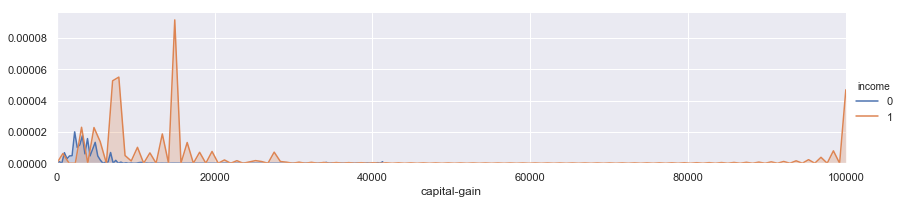

In [50]:
facet = sns.FacetGrid(data, hue='income',aspect=4)
facet.map(sns.kdeplot,'capital-gain',shade= True)
facet.set(xlim=(0, data['capital-gain'].max()))
facet.add_legend()

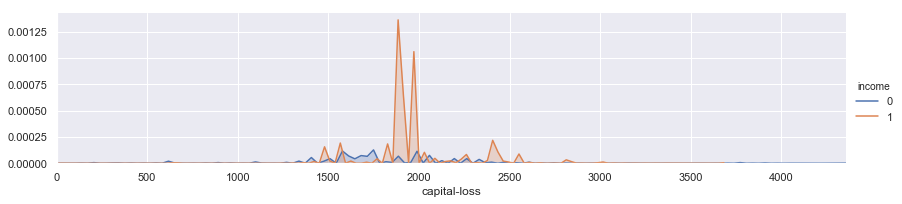

In [51]:
facet = sns.FacetGrid(data, hue='income',aspect=4)
facet.map(sns.kdeplot,'capital-loss',shade= True)
facet.set(xlim=(0, data['capital-loss'].max()))
facet.add_legend()

In [52]:
data[data['capital-loss']>0].income.count()/data.income.count()

0.05410295616717635

In [53]:
data[data['capital-gain']>0].income.count()/data.income.count()

0.09561671763506625

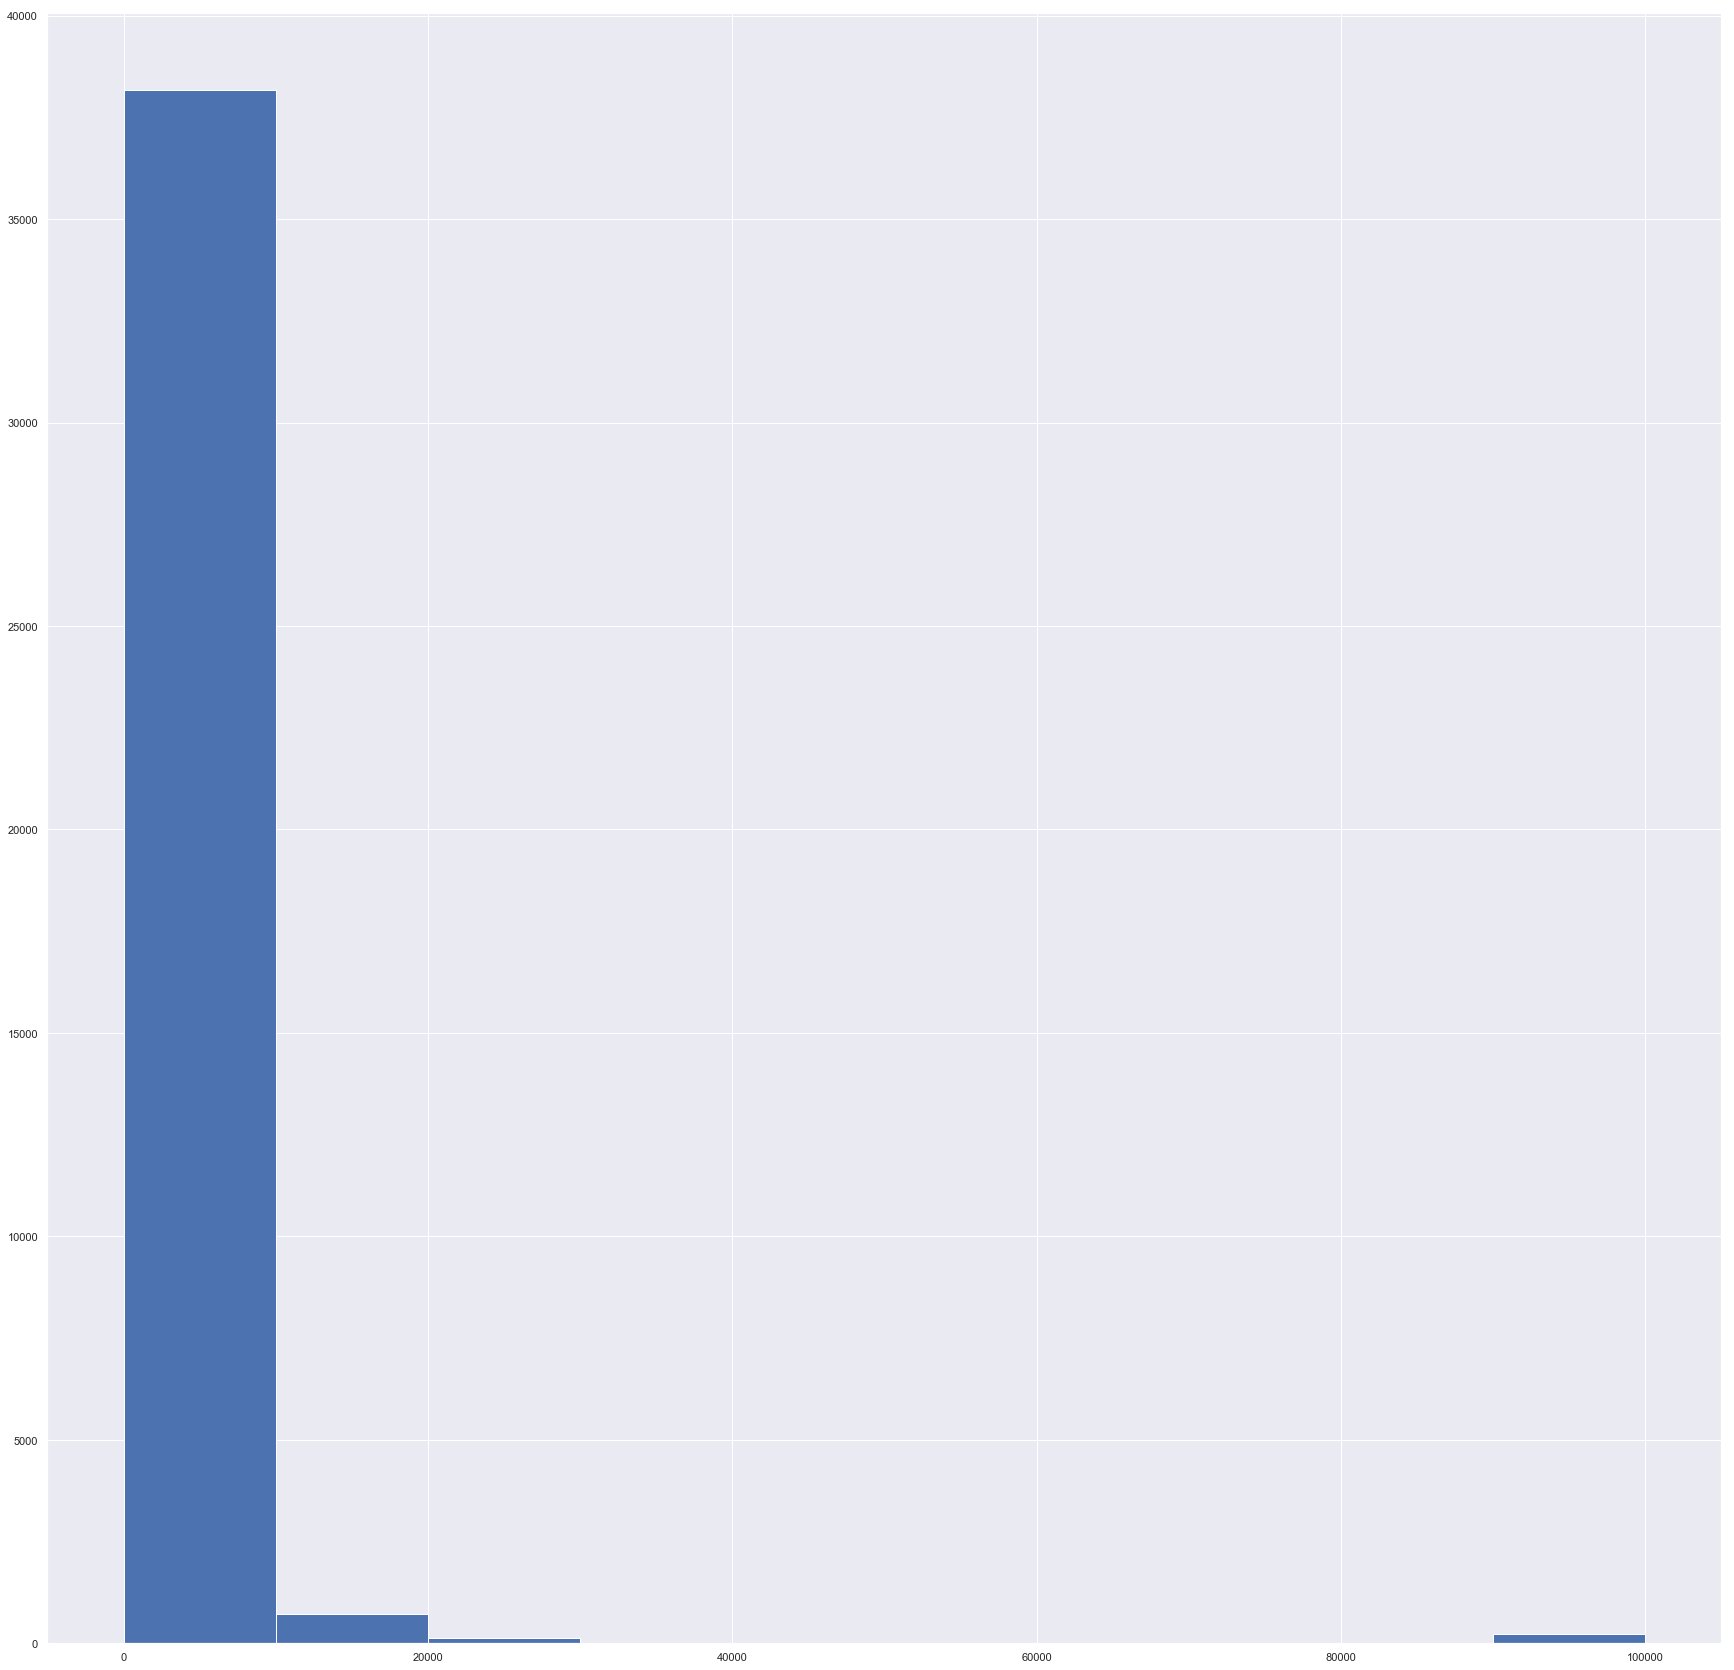

In [54]:
data['capital-gain'].hist(bins=10)

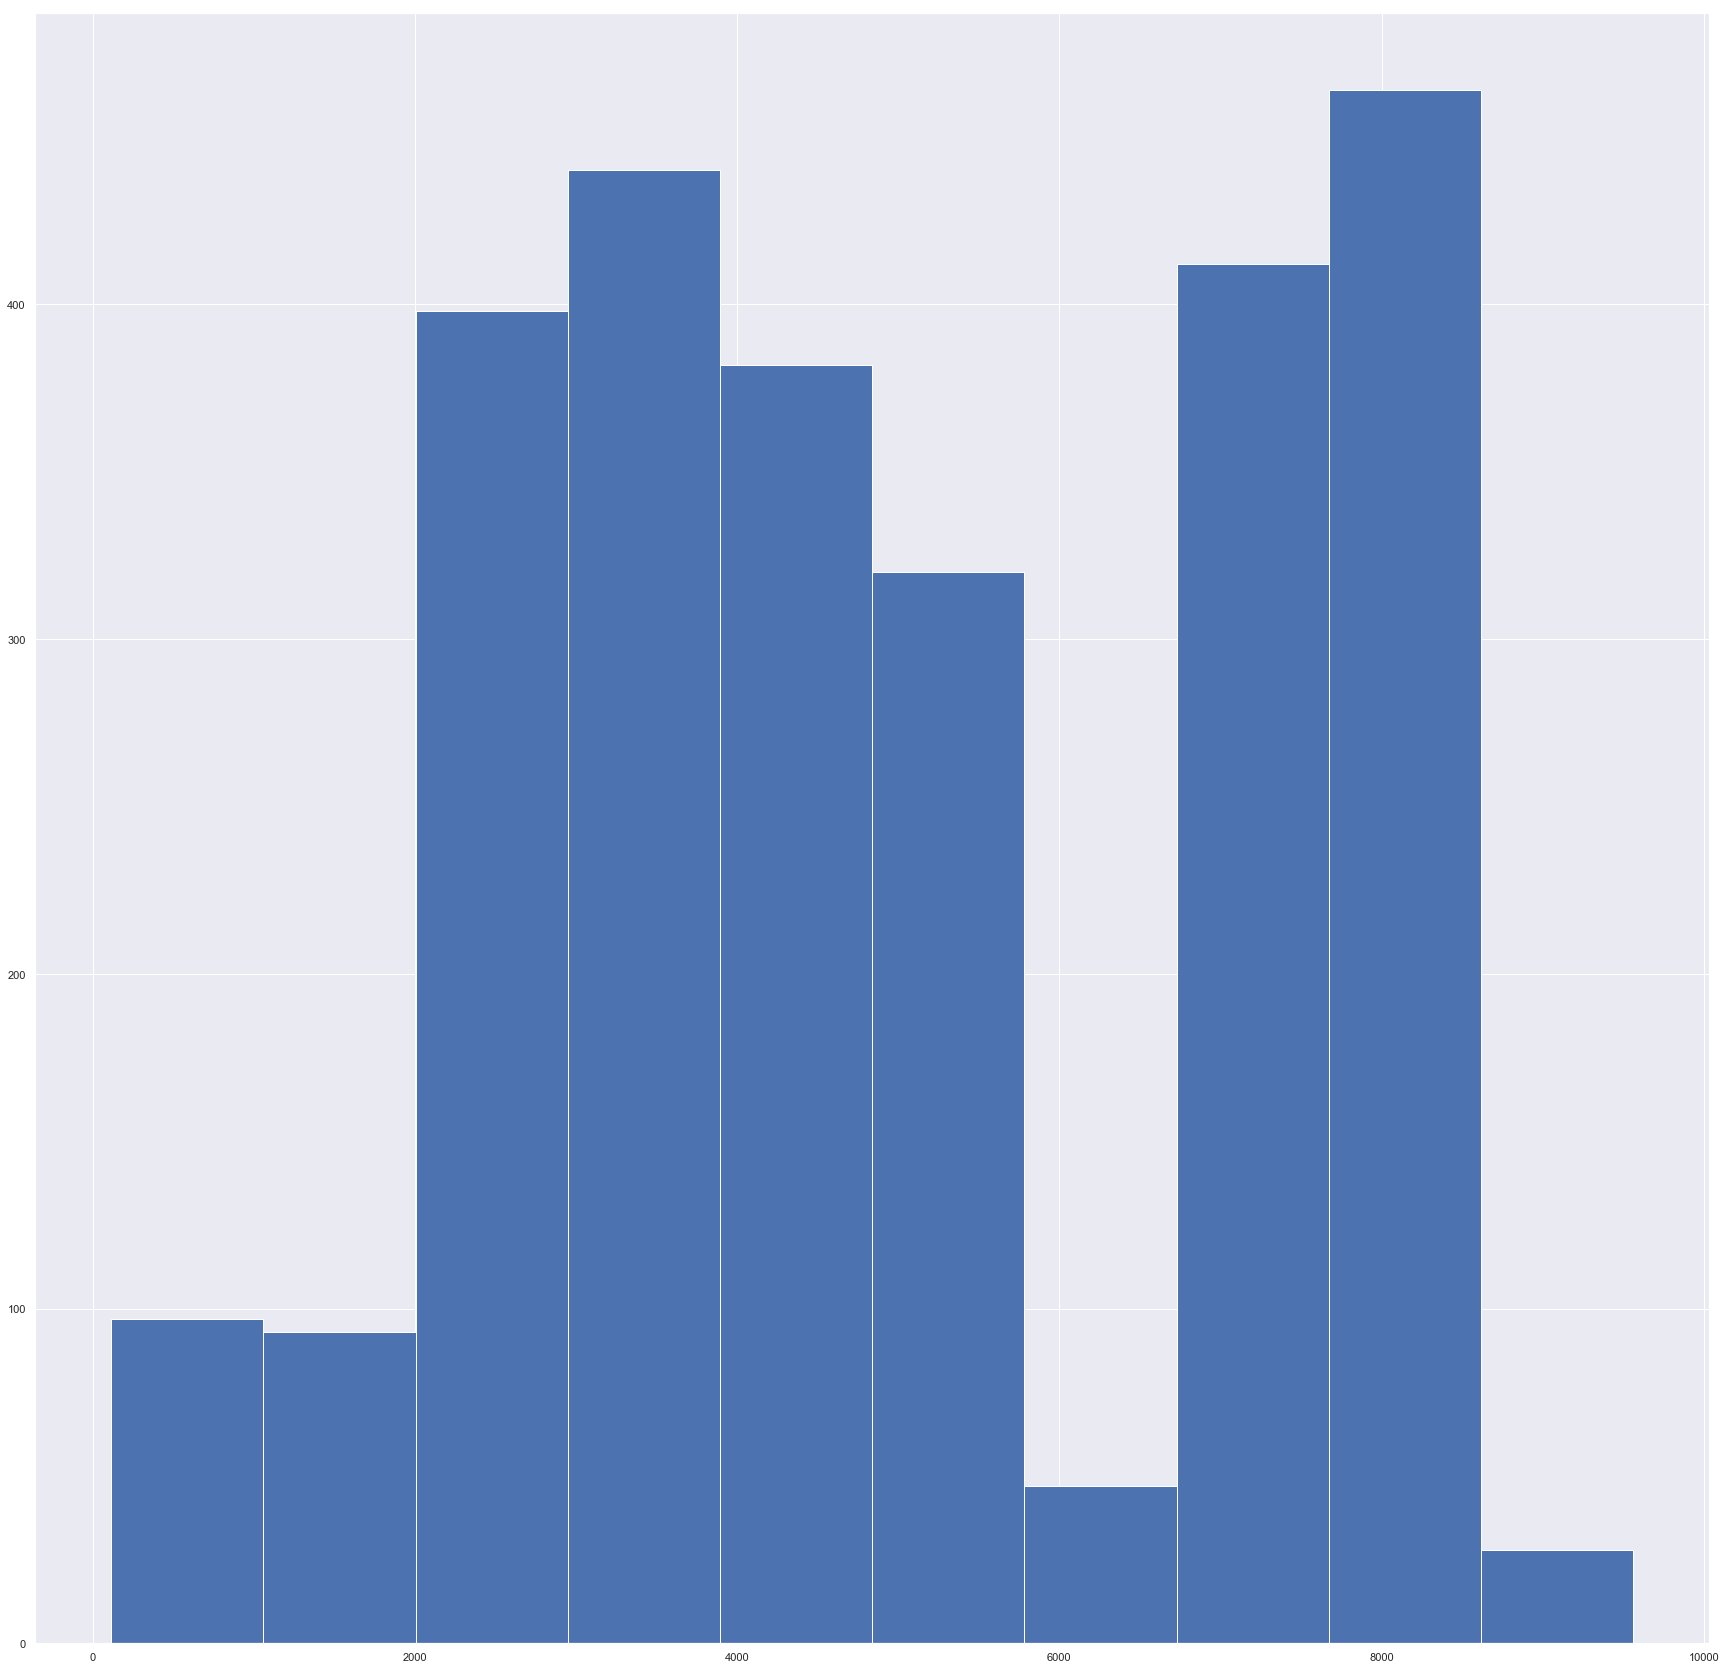

In [55]:
data[(data['capital-gain']<10000)&(data['capital-gain']>0)]['capital-gain'].hist()

In [56]:
map_gain ={(0,1):0,(1,2000):1,(2000,6000):2,(6000,10000):3,(10000,data['capital-gain'].max()):4}

In [57]:
data['asset_gain'] = 0
for key in map_gain:
    i = data[(data['capital-gain']>=key[0])&(data['capital-gain']<key[1])].index
    data['asset_gain'].iloc[i] = map_gain[key]
data.head(n=10)

,education_num,sex,capital-gain,capital-loss,hours-per-week,income,age_grp,Profession,relation_status,geography,asset_gain
0,0.415823,1,2174.0,0.0,40.0,0,0.314302,0.116667,0.102533,0.279548,2
1,0.415823,1,0.0,0.0,13.0,0,0.403834,0.366426,0.468530,0.279548,0
2,0.170457,1,0.0,0.0,40.0,0,0.314302,0.067050,0.136747,0.279548,0
3,0.061885,1,0.0,0.0,40.0,0,0.403834,0.067050,0.468530,0.130230,0
4,0.415823,0,0.0,0.0,40.0,0,0.119467,0.434976,0.486146,0.250000,0
5,0.542639,0,0.0,0.0,40.0,0,0.314302,0.459760,0.486146,0.279548,0
6,0.057751,0,0.0,0.0,16.0,0,0.389276,0.039377,0.141844,0.127660,0
7,0.170457,1,0.0,0.0,45.0,1,0.403834,0.366426,0.468530,0.279548,0
8,0.542639,0,14084.0,0.0,50.0,1,0.232601,0.434976,0.102533,0.279548,4
9,0.415823,1,5178.0,0.0,40.0,1,0.354945,0.459760,0.468530,0.279548,2


In [58]:
xg = data.groupby('asset_gain').income.sum()/data.groupby('asset_gain').income.count()
xg

asset_gain
0    0.220082
1    0.000000
2    0.267532
3    0.919033
4    0.981065
Name: income, dtype: float64

In [59]:
data.asset_gain.replace(xg.index,xg.as_matrix(),inplace=True)
data.head(n=10)

/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:1: FutureWarning: Method .as_matrix will be removed in a future version. Use .values instead.
  """Entry point for launching an IPython kernel.


,education_num,sex,capital-gain,capital-loss,hours-per-week,income,age_grp,Profession,relation_status,geography,asset_gain
0,0.415823,1,2174.0,0.0,40.0,0,0.314302,0.116667,0.102533,0.279548,0.267532
1,0.415823,1,0.0,0.0,13.0,0,0.403834,0.366426,0.468530,0.279548,0.220082
2,0.170457,1,0.0,0.0,40.0,0,0.314302,0.067050,0.136747,0.279548,0.220082
3,0.061885,1,0.0,0.0,40.0,0,0.403834,0.067050,0.468530,0.130230,0.220082
4,0.415823,0,0.0,0.0,40.0,0,0.119467,0.434976,0.486146,0.250000,0.220082
5,0.542639,0,0.0,0.0,40.0,0,0.314302,0.459760,0.486146,0.279548,0.220082
6,0.057751,0,0.0,0.0,16.0,0,0.389276,0.039377,0.141844,0.127660,0.220082
7,0.170457,1,0.0,0.0,45.0,1,0.403834,0.366426,0.468530,0.279548,0.220082
8,0.542639,0,14084.0,0.0,50.0,1,0.232601,0.434976,0.102533,0.279548,0.981065
9,0.415823,1,5178.0,0.0,40.0,1,0.354945,0.459760,0.468530,0.279548,0.267532


In [60]:
data.drop('capital-gain',axis=1,inplace=True)

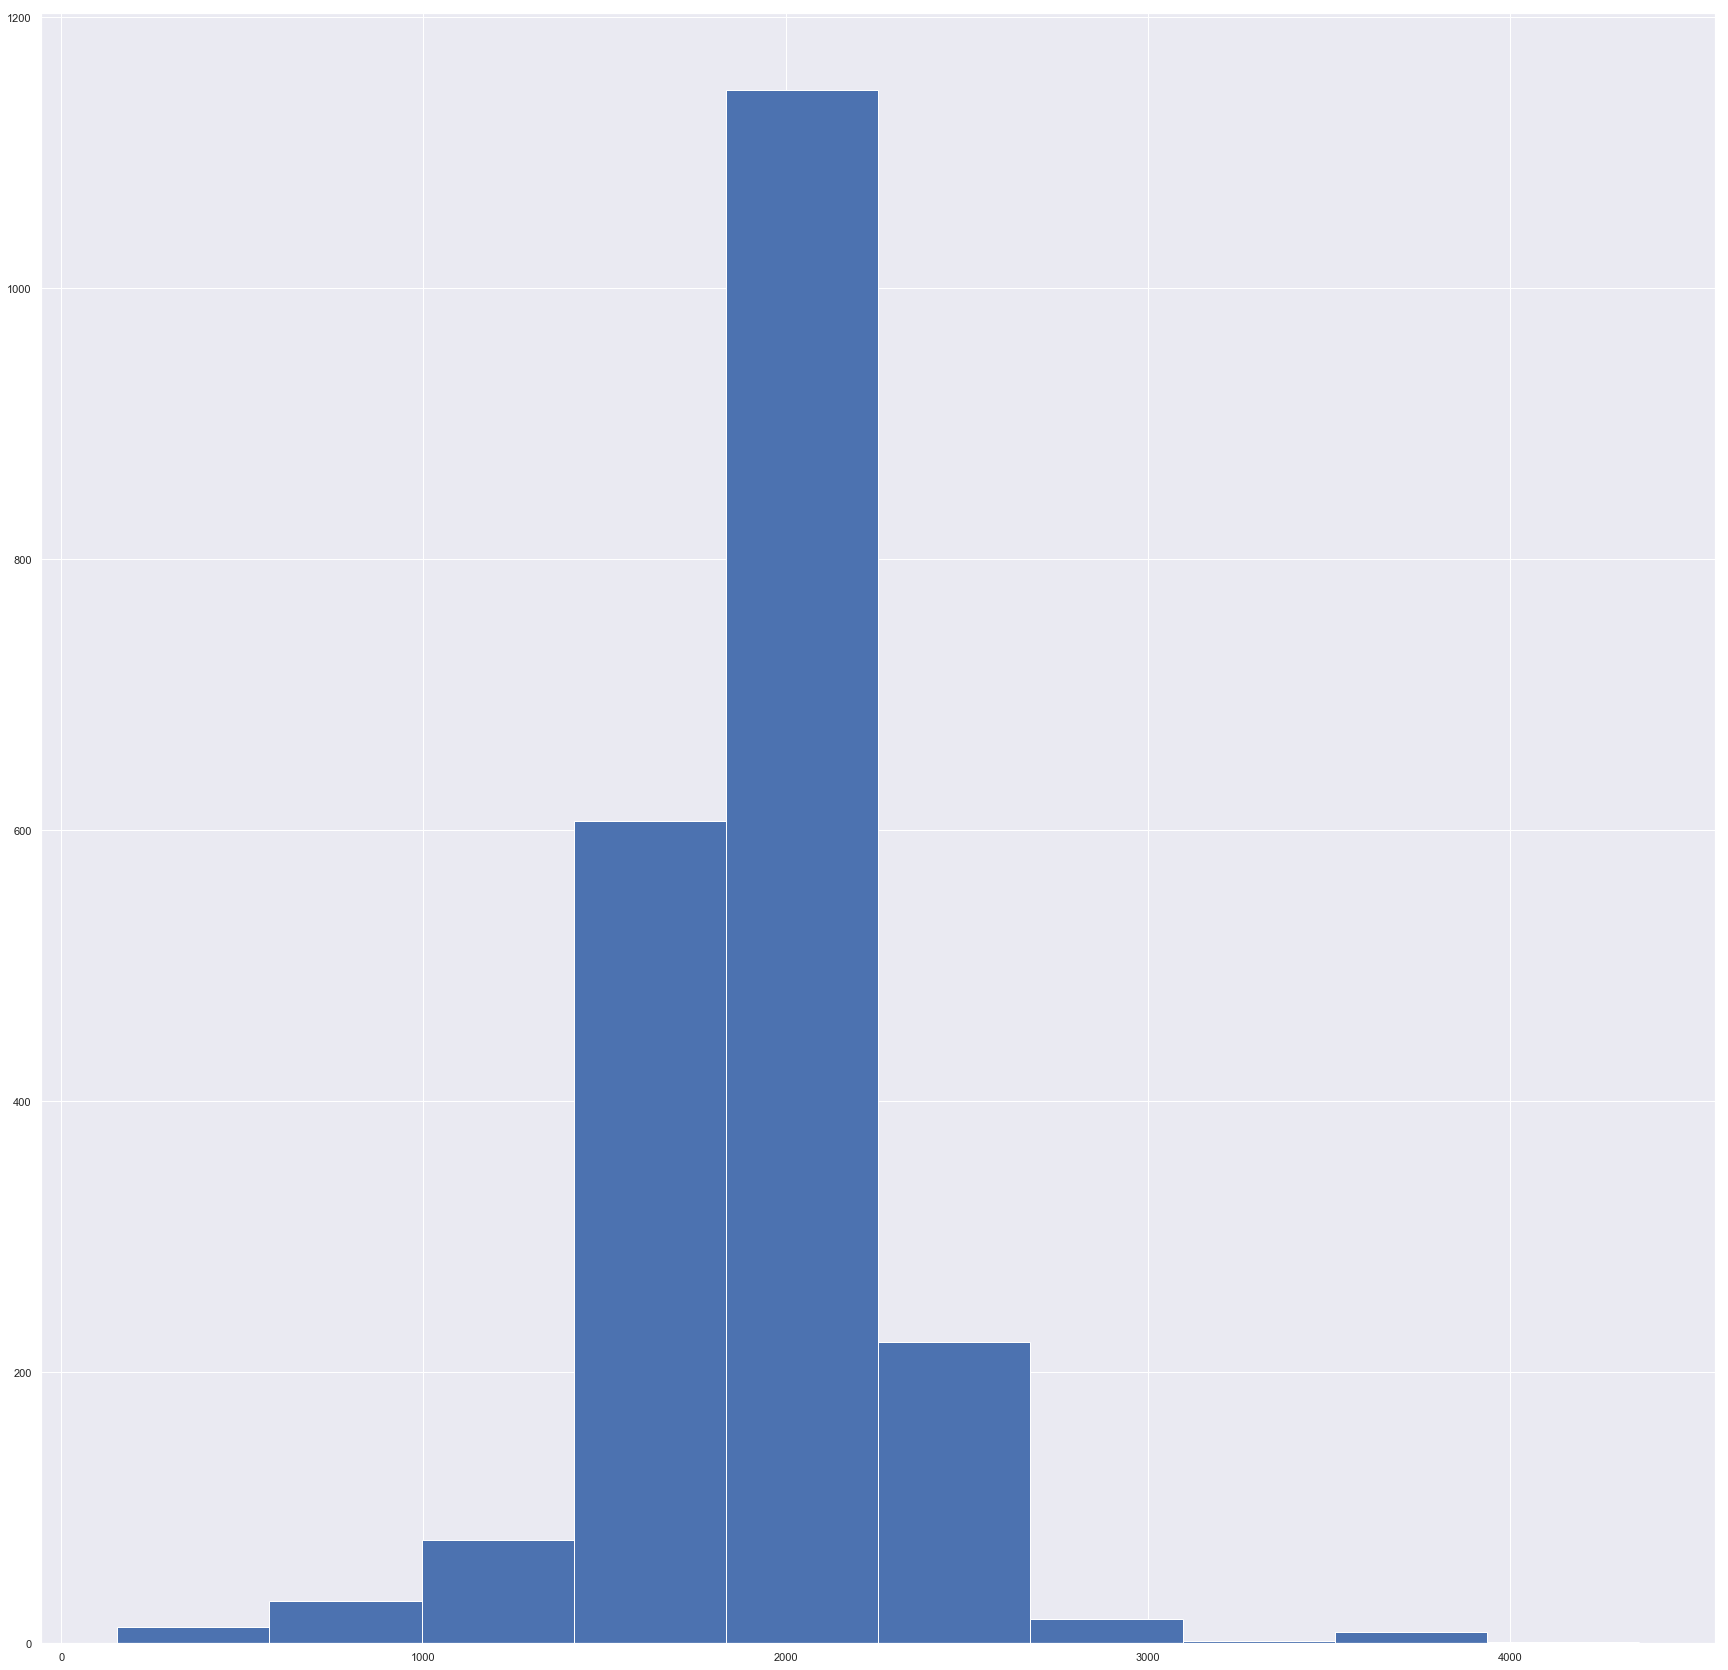

In [61]:
data[data['capital-loss']>0]['capital-loss'].hist()

In [62]:
map_loss ={(0,1):0,(1,1800):1,(1800,2000):2,(2000,data['capital-loss'].max()):3}

In [63]:
data['asset_loss'] = 0
for key in map_loss:
    i = data[(data['capital-loss']>=key[0])&(data['capital-loss']<key[1])].index
    data['asset_loss'].iloc[i] = map_loss[key]
data.head(n=10)

,education_num,sex,capital-loss,hours-per-week,income,age_grp,Profession,relation_status,geography,asset_gain,asset_loss
0,0.415823,1,0.0,40.0,0,0.314302,0.116667,0.102533,0.279548,0.267532,0
1,0.415823,1,0.0,13.0,0,0.403834,0.366426,0.468530,0.279548,0.220082,0
2,0.170457,1,0.0,40.0,0,0.314302,0.067050,0.136747,0.279548,0.220082,0
3,0.061885,1,0.0,40.0,0,0.403834,0.067050,0.468530,0.130230,0.220082,0
4,0.415823,0,0.0,40.0,0,0.119467,0.434976,0.486146,0.250000,0.220082,0
5,0.542639,0,0.0,40.0,0,0.314302,0.459760,0.486146,0.279548,0.220082,0
6,0.057751,0,0.0,16.0,0,0.389276,0.039377,0.141844,0.127660,0.220082,0
7,0.170457,1,0.0,45.0,1,0.403834,0.366426,0.468530,0.279548,0.220082,0
8,0.542639,0,0.0,50.0,1,0.232601,0.434976,0.102533,0.279548,0.981065,0
9,0.415823,1,0.0,40.0,1,0.354945,0.459760,0.468530,0.279548,0.267532,0


In [64]:
xl = data.groupby('asset_loss').income.sum()/data.groupby('asset_loss').income.count()
xl

asset_loss
0    0.239560
1    0.119444
2    0.845026
3    0.425056
Name: income, dtype: float64

In [65]:
data.asset_loss.replace(xl.index,xl.as_matrix(),inplace=True)
data.head(n=10)

/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:1: FutureWarning: Method .as_matrix will be removed in a future version. Use .values instead.
  """Entry point for launching an IPython kernel.


,education_num,sex,capital-loss,hours-per-week,income,age_grp,Profession,relation_status,geography,asset_gain,asset_loss
0,0.415823,1,0.0,40.0,0,0.314302,0.116667,0.102533,0.279548,0.267532,0.23956
1,0.415823,1,0.0,13.0,0,0.403834,0.366426,0.468530,0.279548,0.220082,0.23956
2,0.170457,1,0.0,40.0,0,0.314302,0.067050,0.136747,0.279548,0.220082,0.23956
3,0.061885,1,0.0,40.0,0,0.403834,0.067050,0.468530,0.130230,0.220082,0.23956
4,0.415823,0,0.0,40.0,0,0.119467,0.434976,0.486146,0.250000,0.220082,0.23956
5,0.542639,0,0.0,40.0,0,0.314302,0.459760,0.486146,0.279548,0.220082,0.23956
6,0.057751,0,0.0,16.0,0,0.389276,0.039377,0.141844,0.127660,0.220082,0.23956
7,0.170457,1,0.0,45.0,1,0.403834,0.366426,0.468530,0.279548,0.220082,0.23956
8,0.542639,0,0.0,50.0,1,0.232601,0.434976,0.102533,0.279548,0.981065,0.23956
9,0.415823,1,0.0,40.0,1,0.354945,0.459760,0.468530,0.279548,0.267532,0.23956


In [66]:
data.drop('capital-loss',axis=1,inplace=True)

### Hours

In [67]:
data.rename(columns={'hours-per-week':'hours'},inplace=True)
data.head()

,education_num,sex,hours,income,age_grp,Profession,relation_status,geography,asset_gain,asset_loss
0,0.415823,1,40.0,0,0.314302,0.116667,0.102533,0.279548,0.267532,0.23956
1,0.415823,1,13.0,0,0.403834,0.366426,0.468530,0.279548,0.220082,0.23956
2,0.170457,1,40.0,0,0.314302,0.067050,0.136747,0.279548,0.220082,0.23956
3,0.061885,1,40.0,0,0.403834,0.067050,0.468530,0.130230,0.220082,0.23956
4,0.415823,0,40.0,0,0.119467,0.434976,0.486146,0.250000,0.220082,0.23956


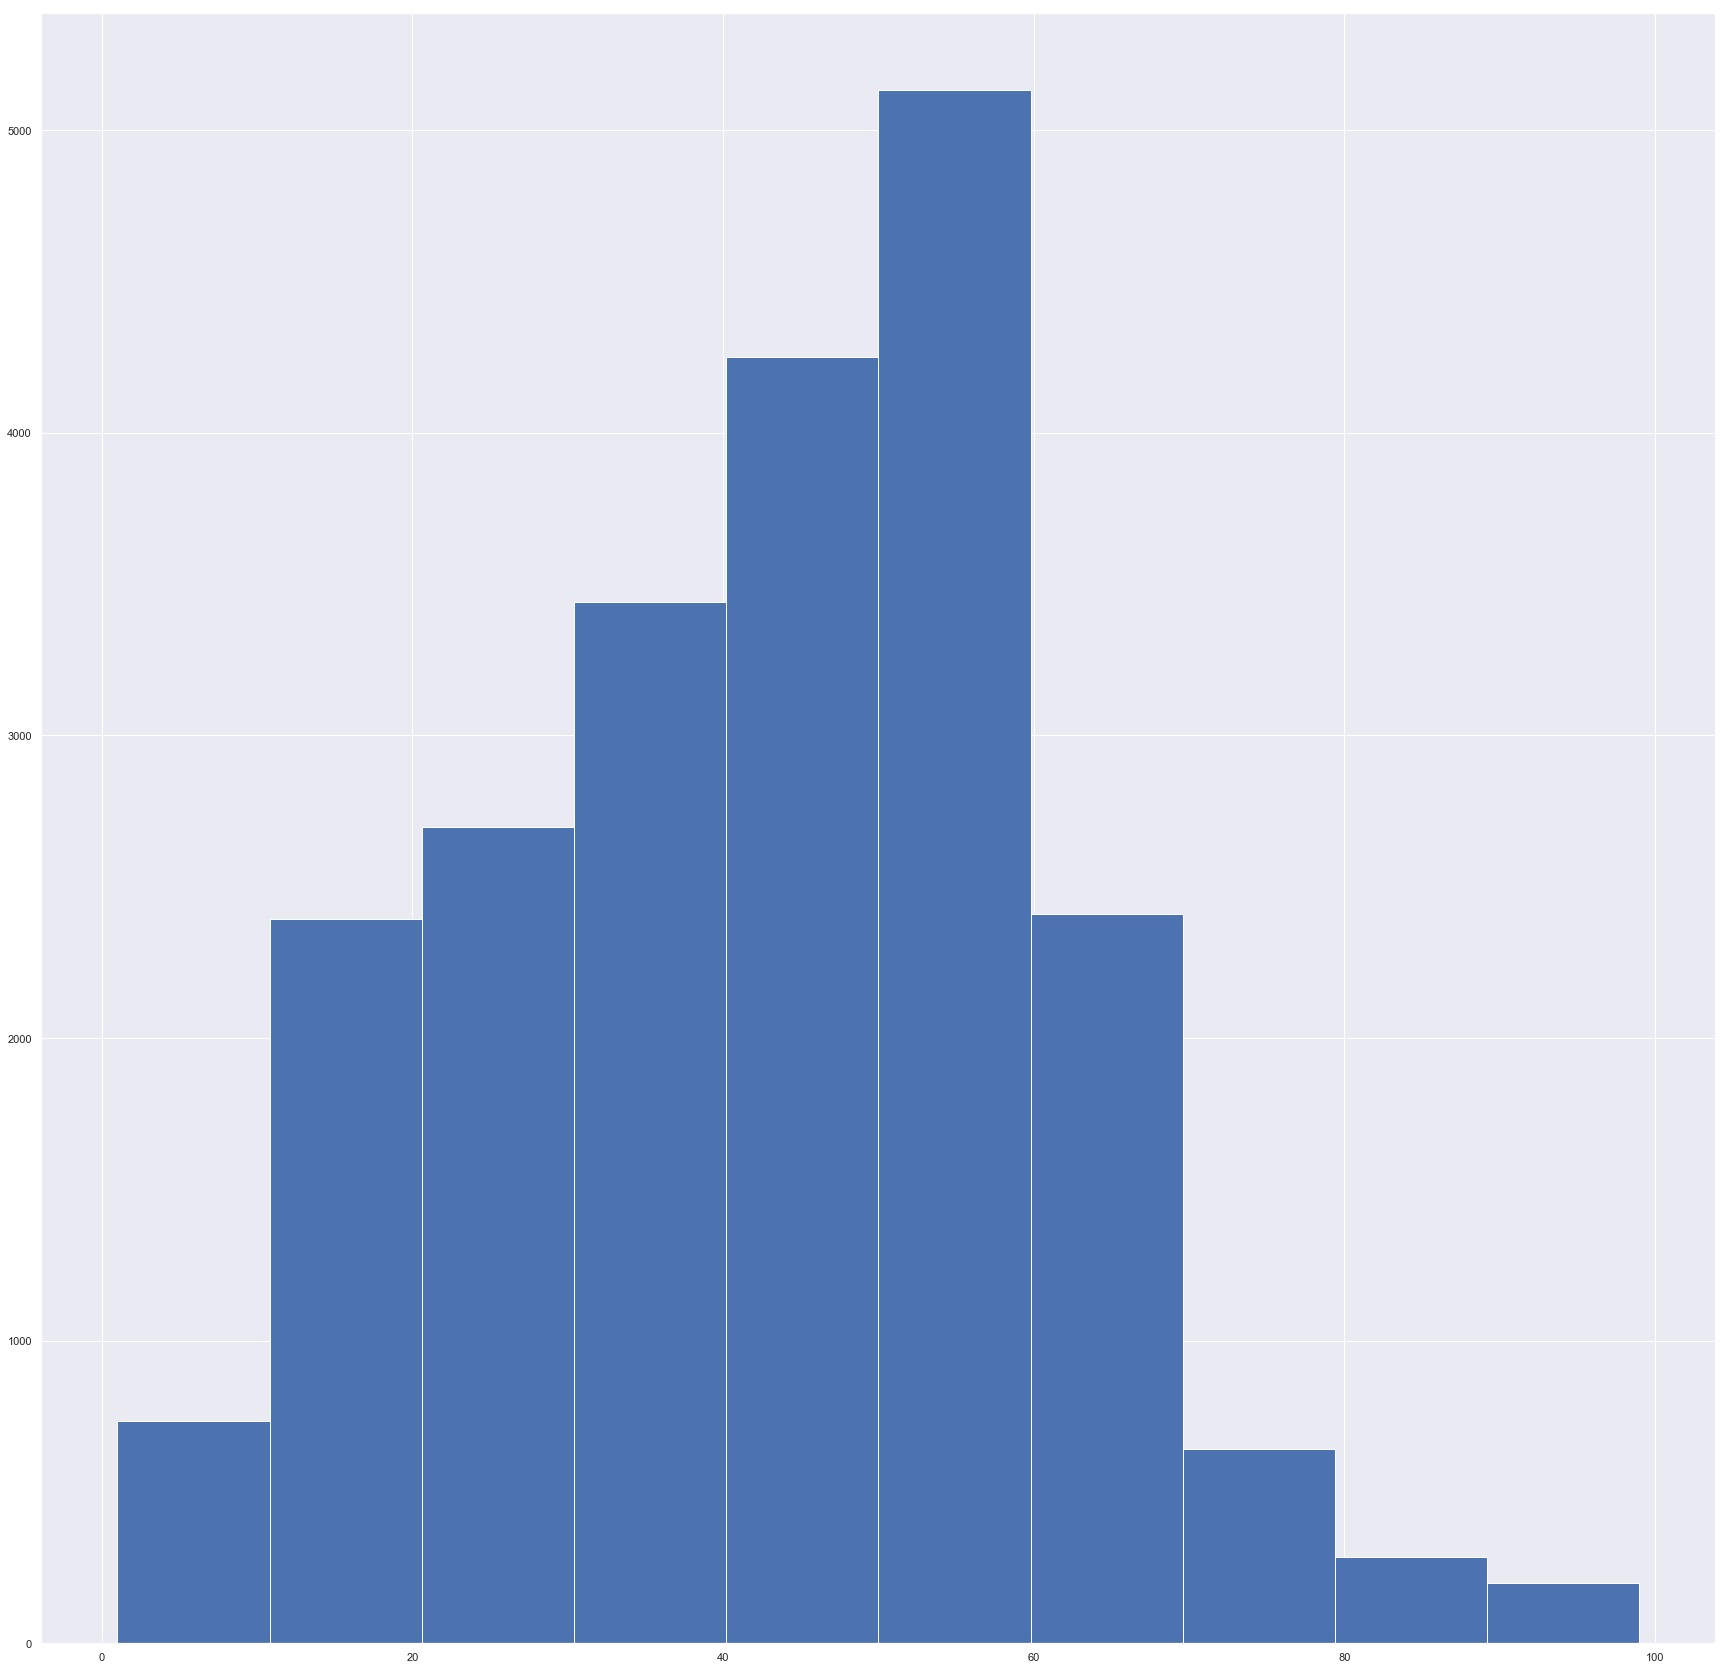

In [68]:
data[(data.hours!=40.0)].hours.hist(bins=10)

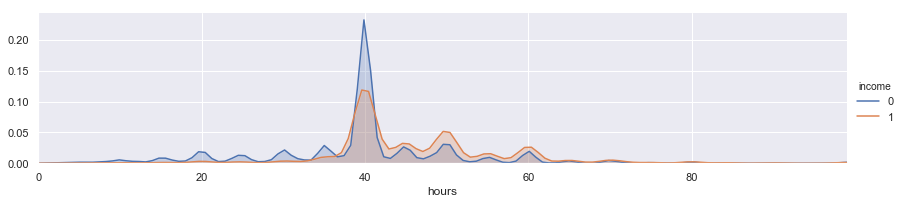

In [69]:
facet = sns.FacetGrid(data, hue='income',aspect=4)
facet.map(sns.kdeplot,'hours',shade= True)
facet.set(xlim=(0, data['hours'].max()))
facet.add_legend()

In [70]:
map_hours = {(0,20):0,(20,39):1,(39,41):2,(41,60):3,(60,80):4,(80,100):5}
data['hours_mod'] = 0
for key in map_hours:
    i = data[(data.hours>=key[0])&(data.hours<key[1])].index
    data['hours_mod'].iloc[i] = map_hours[key]
data.head(n=10)

,education_num,sex,hours,income,age_grp,Profession,relation_status,geography,asset_gain,asset_loss,hours_mod
0,0.415823,1,40.0,0,0.314302,0.116667,0.102533,0.279548,0.267532,0.23956,2
1,0.415823,1,13.0,0,0.403834,0.366426,0.468530,0.279548,0.220082,0.23956,0
2,0.170457,1,40.0,0,0.314302,0.067050,0.136747,0.279548,0.220082,0.23956,2
3,0.061885,1,40.0,0,0.403834,0.067050,0.468530,0.130230,0.220082,0.23956,2
4,0.415823,0,40.0,0,0.119467,0.434976,0.486146,0.250000,0.220082,0.23956,2
5,0.542639,0,40.0,0,0.314302,0.459760,0.486146,0.279548,0.220082,0.23956,2
6,0.057751,0,16.0,0,0.389276,0.039377,0.141844,0.127660,0.220082,0.23956,0
7,0.170457,1,45.0,1,0.403834,0.366426,0.468530,0.279548,0.220082,0.23956,3
8,0.542639,0,50.0,1,0.232601,0.434976,0.102533,0.279548,0.981065,0.23956,3
9,0.415823,1,40.0,1,0.354945,0.459760,0.468530,0.279548,0.267532,0.23956,2


In [71]:
xh = data.groupby('hours_mod').income.sum()/data.groupby('hours_mod').income.count()
xh

hours_mod
0    0.073911
1    0.111487
2    0.226006
3    0.395800
4    0.413229
5    0.358921
Name: income, dtype: float64

In [72]:
data.hours_mod.replace(xh.index,xh.as_matrix(),inplace=True)
data.head(n=10)

/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:1: FutureWarning: Method .as_matrix will be removed in a future version. Use .values instead.
  """Entry point for launching an IPython kernel.


,education_num,sex,hours,income,age_grp,Profession,relation_status,geography,asset_gain,asset_loss,hours_mod
0,0.415823,1,40.0,0,0.314302,0.116667,0.102533,0.279548,0.267532,0.23956,0.226006
1,0.415823,1,13.0,0,0.403834,0.366426,0.468530,0.279548,0.220082,0.23956,0.073911
2,0.170457,1,40.0,0,0.314302,0.067050,0.136747,0.279548,0.220082,0.23956,0.226006
3,0.061885,1,40.0,0,0.403834,0.067050,0.468530,0.130230,0.220082,0.23956,0.226006
4,0.415823,0,40.0,0,0.119467,0.434976,0.486146,0.250000,0.220082,0.23956,0.226006
5,0.542639,0,40.0,0,0.314302,0.459760,0.486146,0.279548,0.220082,0.23956,0.226006
6,0.057751,0,16.0,0,0.389276,0.039377,0.141844,0.127660,0.220082,0.23956,0.073911
7,0.170457,1,45.0,1,0.403834,0.366426,0.468530,0.279548,0.220082,0.23956,0.395800
8,0.542639,0,50.0,1,0.232601,0.434976,0.102533,0.279548,0.981065,0.23956,0.395800
9,0.415823,1,40.0,1,0.354945,0.459760,0.468530,0.279548,0.267532,0.23956,0.226006


In [73]:
data.drop('hours', axis=1,inplace=True)

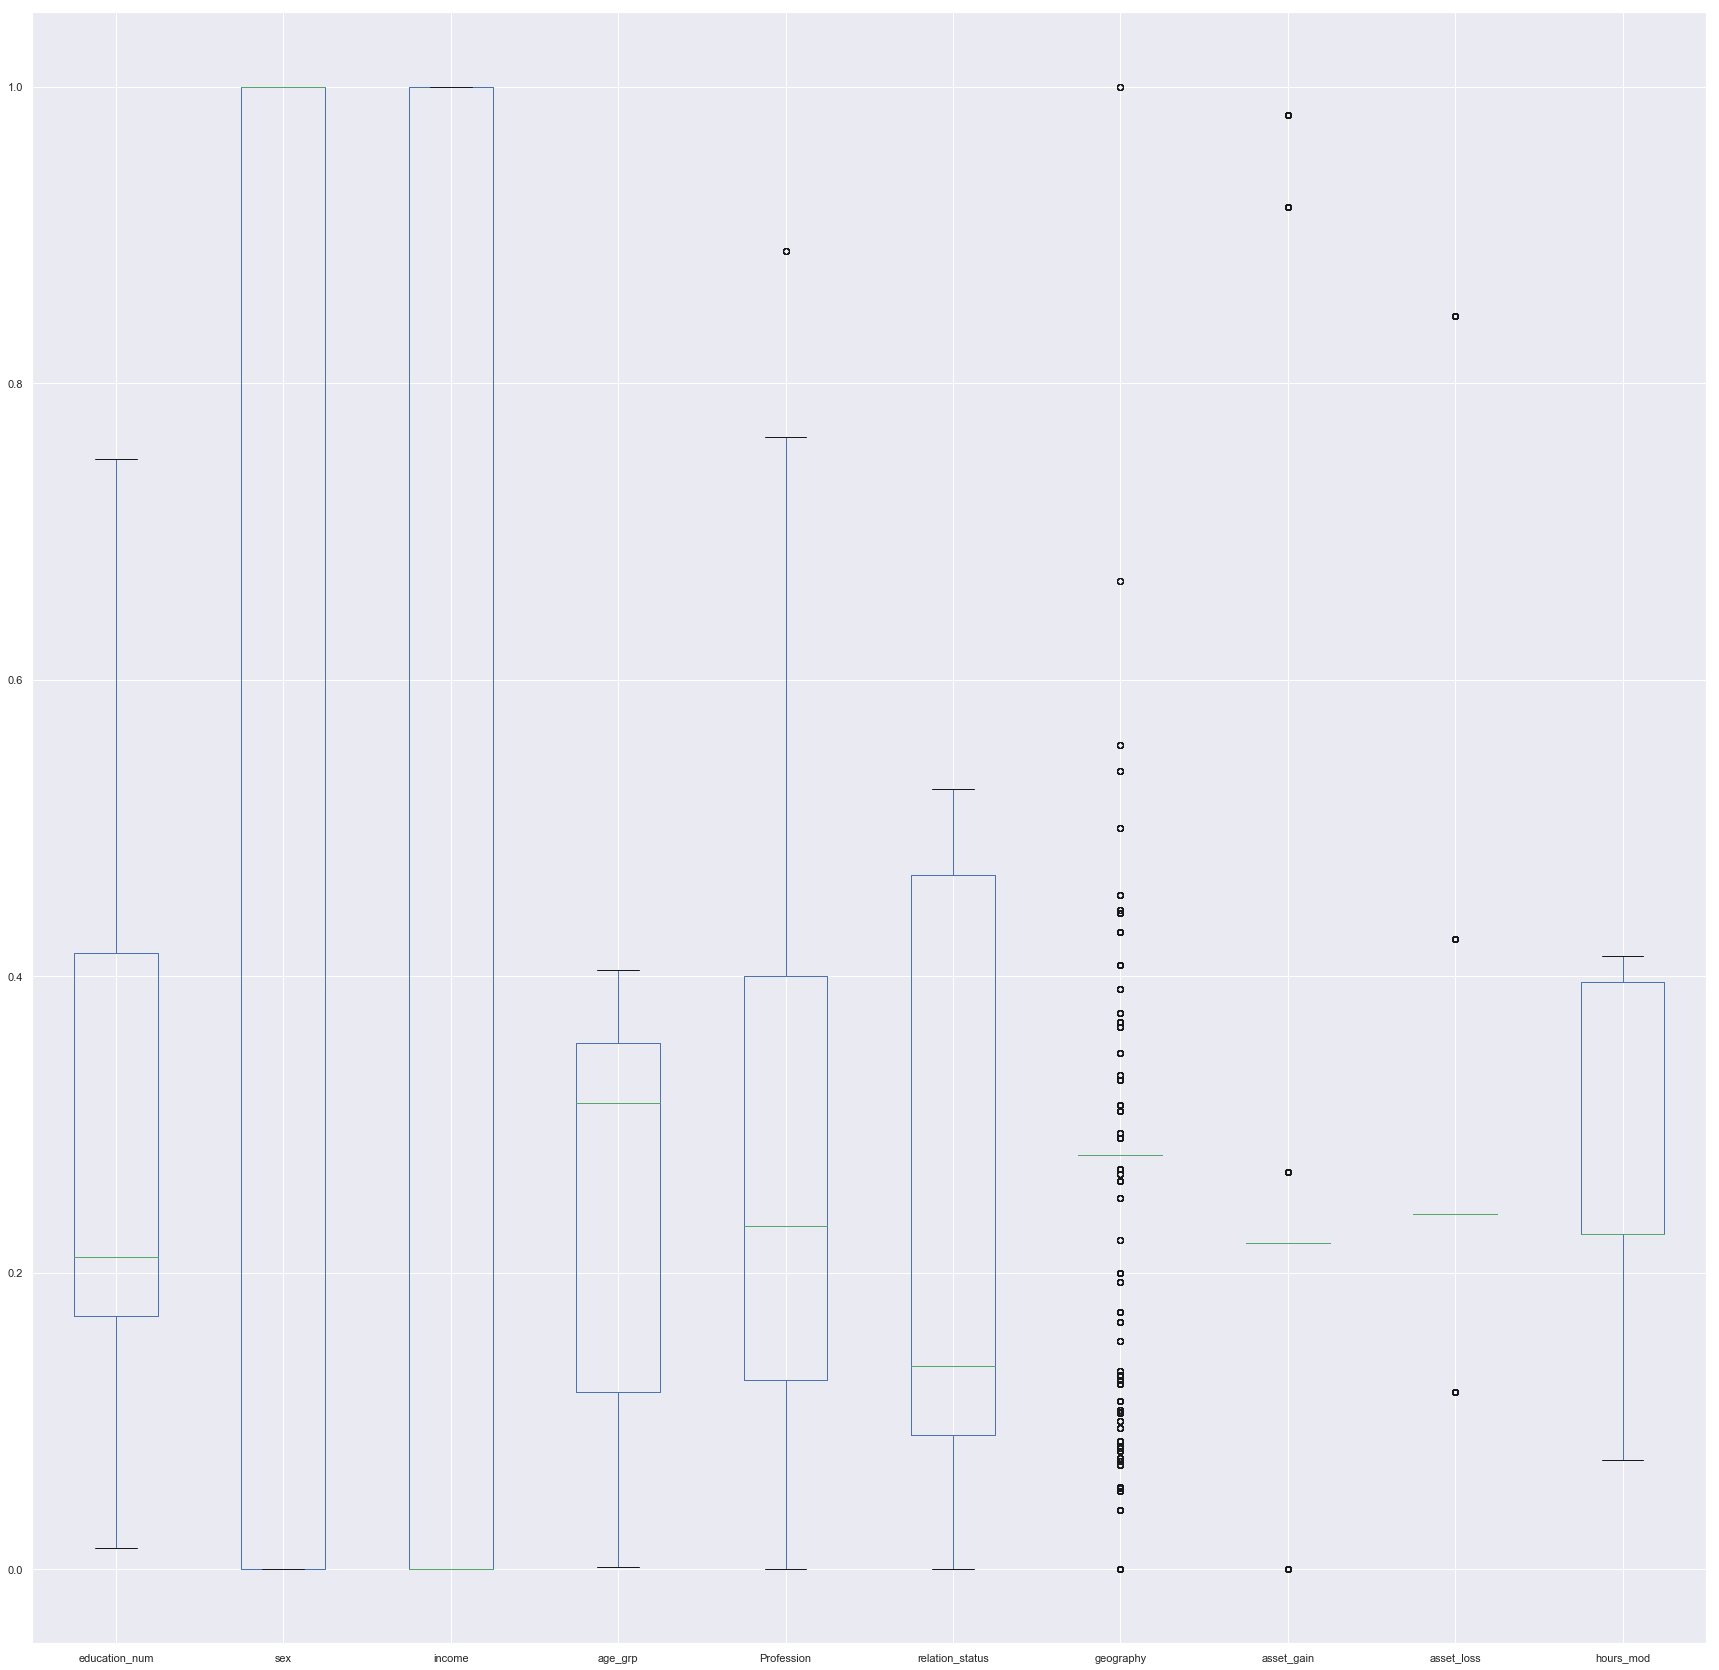

In [74]:
data.boxplot()

In [88]:
# Import sklearn.preprocessing.StandardScaler
from sklearn.preprocessing import RobustScaler

# Initialize a scaler, then apply it to the features
scaler = RobustScaler() # default=(0, 1)
numerical = data.columns
features = pd.DataFrame(data=data)
features[numerical] = scaler.fit_transform(data[numerical])

# Show an example of a record with scaling applied
features.head(n=20)

,education_num,sex,income,age_grp,Profession,relation_status,geography,asset_gain,asset_loss,hours_mod
0,0.836900,0.0,0.0,0.000000,-0.419531,-0.090552,0.000000,0.048367,0.0,0.000000
1,0.836900,0.0,0.0,0.380218,0.496038,0.878110,0.000000,0.000000,0.0,-0.895766
2,-0.163100,0.0,0.0,0.000000,-0.601417,0.000000,0.000000,0.000000,0.0,0.000000
3,-0.605593,0.0,0.0,0.380218,-0.601417,0.878110,-0.149318,0.000000,0.0,0.000000
4,0.836900,-1.0,0.0,-0.827402,0.747329,0.924733,-0.029548,0.000000,0.0,0.000000
5,1.353743,-1.0,0.0,0.000000,0.838181,0.924733,0.000000,0.000000,0.0,0.000000
6,-0.622441,-1.0,0.0,0.318392,-0.702860,0.013490,-0.151888,0.000000,0.0,-0.895766
7,-0.163100,0.0,1.0,0.380218,0.496038,0.878110,0.000000,0.000000,0.0,1.000000
8,1.353743,-1.0,1.0,-0.346956,0.747329,-0.090552,0.000000,0.775671,0.0,1.000000
9,0.836900,0.0,1.0,0.172598,0.838181,0.878110,0.000000,0.048367,0.0,0.000000


In [89]:
features[features.income>0].head(n=50)

,education_num,sex,income,age_grp,Profession,relation_status,geography,asset_gain,asset_loss,hours_mod
7,-0.163100,0.0,1.0,0.380218,0.496038,0.878110,0.000000,0.000000,0.000000,1.000000
8,1.353743,-1.0,1.0,-0.346956,0.747329,-0.090552,0.000000,0.775671,0.000000,1.000000
9,0.836900,0.0,1.0,0.172598,0.838181,0.878110,0.000000,0.048367,0.000000,0.000000
10,0.000000,0.0,1.0,0.000000,0.838181,0.878110,-0.149318,0.000000,0.000000,0.782802
11,0.836900,0.0,1.0,-0.346956,0.620352,0.878110,0.150204,0.000000,0.000000,0.000000
18,1.353743,-1.0,1.0,0.172598,0.496038,-0.121890,0.000000,0.000000,0.000000,1.000000
19,2.102000,0.0,1.0,0.172598,0.747329,0.878110,0.000000,0.000000,0.000000,1.102645
24,0.836900,0.0,1.0,0.138312,0.480066,0.878110,0.000000,0.000000,0.000000,0.000000
42,0.836900,0.0,1.0,0.138312,1.137769,0.878110,-0.149318,0.000000,0.000000,0.000000
48,2.193517,-1.0,1.0,0.318392,0.747329,0.924733,-0.146215,0.000000,0.834456,1.102645


In [90]:
features[(features.income>0)&(features.Profession<0)&(features.relation_status<0)].head(n=20)

,education_num,sex,income,age_grp,Profession,relation_status,geography,asset_gain,asset_loss,hours_mod
479,0.000000,0.0,1.0,0.172598,-0.394149,-0.121890,0.000000,0.000000,0.000000,1.000000
539,-0.577963,0.0,1.0,-0.102776,-0.038541,-0.090552,0.000000,0.000000,0.000000,1.000000
753,-0.163100,0.0,1.0,0.138312,-0.038541,-0.125612,0.000000,0.000000,-0.165544,1.000000
1096,0.836900,0.0,1.0,0.172598,-0.702860,-0.090552,0.000000,0.000000,0.000000,0.000000
1207,-0.163100,-1.0,1.0,0.380218,-0.702860,-0.125612,0.150204,0.000000,0.000000,0.000000
1269,-0.577972,0.0,1.0,0.172598,-0.038541,-0.298743,0.000000,0.000000,0.000000,0.000000
2281,-0.163100,0.0,1.0,0.138312,-0.168356,-0.076957,0.000000,0.000000,0.000000,1.000000
2283,-0.163100,0.0,1.0,-0.346956,-0.168356,-0.090552,0.000000,0.000000,0.000000,1.000000
3368,0.000000,0.0,1.0,0.172598,-0.379648,-0.298743,0.000000,0.000000,0.000000,1.000000
3402,0.198897,0.0,1.0,-1.246055,-0.379648,-0.090552,0.000000,0.000000,0.000000,-0.674461


### Train and Test

In [91]:
income = features['income']
features = features.drop('income', axis = 1)

In [92]:
features.head()

,education_num,sex,age_grp,Profession,relation_status,geography,asset_gain,asset_loss,hours_mod
0,0.836900,0.0,0.000000,-0.419531,-0.090552,0.000000,0.048367,0.0,0.000000
1,0.836900,0.0,0.380218,0.496038,0.878110,0.000000,0.000000,0.0,-0.895766
2,-0.163100,0.0,0.000000,-0.601417,0.000000,0.000000,0.000000,0.0,0.000000
3,-0.605593,0.0,0.380218,-0.601417,0.878110,-0.149318,0.000000,0.0,0.000000
4,0.836900,-1.0,-0.827402,0.747329,0.924733,-0.029548,0.000000,0.0,0.000000


### Implementation: Data Exploration
A cursory investigation of the dataset will determine how many individuals fit into either group, and will tell us about the percentage of these individuals making more than \$50,000. In the code cell below, you will need to compute the following:
- The total number of records, `'n_records'`
- The number of individuals making more than \$50,000 annually, `'n_greater_50k'`.
- The number of individuals making at most \$50,000 annually, `'n_at_most_50k'`.
- The percentage of individuals making more than \$50,000 annually, `'greater_percent'`.

** HINT: ** You may need to look at the table above to understand how the `'income'` entries are formatted. 

### Transforming Skewed Continuous Features
A dataset may sometimes contain at least one feature whose values tend to lie near a single number, but will also have a non-trivial number of vastly larger or smaller values than that single number.  Algorithms can be sensitive to such distributions of values and can underperform if the range is not properly normalized. With the census dataset two features fit this description: '`capital-gain'` and `'capital-loss'`. 

Run the code cell below to plot a histogram of these two features. Note the range of the values present and how they are distributed.

### Implementation: Data Preprocessing

From the table in **Exploring the Data** above, we can see there are several features for each record that are non-numeric. Typically, learning algorithms expect input to be numeric, which requires that non-numeric features (called *categorical variables*) be converted. One popular way to convert categorical variables is by using the **one-hot encoding** scheme. One-hot encoding creates a _"dummy"_ variable for each possible category of each non-numeric feature. For example, assume `someFeature` has three possible entries: `A`, `B`, or `C`. We then encode this feature into `someFeature_A`, `someFeature_B` and `someFeature_C`.

|   | someFeature |                    | someFeature_A | someFeature_B | someFeature_C |
| :-: | :-: |                            | :-: | :-: | :-: |
| 0 |  B  |  | 0 | 1 | 0 |
| 1 |  C  | ----> one-hot encode ----> | 0 | 0 | 1 |
| 2 |  A  |  | 1 | 0 | 0 |

Additionally, as with the non-numeric features, we need to convert the non-numeric target label, `'income'` to numerical values for the learning algorithm to work. Since there are only two possible categories for this label ("<=50K" and ">50K"), we can avoid using one-hot encoding and simply encode these two categories as `0` and `1`, respectively. In code cell below, you will need to implement the following:
 - Use [`pandas.get_dummies()`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html?highlight=get_dummies#pandas.get_dummies) to perform one-hot encoding on the `'features_log_minmax_transform'` data.
 - Convert the target label `'income_raw'` to numerical entries.
   - Set records with "<=50K" to `0` and records with ">50K" to `1`.

### Shuffle and Split Data
Now all _categorical variables_ have been converted into numerical features, and all numerical features have been normalized. As always, we will now split the data (both features and their labels) into training and test sets. 80% of the data will be used for training and 20% for testing.

Run the code cell below to perform this split.

In [112]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the 'features' and 'income' data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, 
                                                    income, 
                                                    test_size = 0.1, 
                                                    random_state = 0)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

Training set has 35316 samples.
Testing set has 3924 samples.


----
## Evaluating Model Performance
In this section, we will investigate four different algorithms, and determine which is best at modeling the data. Three of these algorithms will be supervised learners of your choice, and the fourth algorithm is known as a *naive predictor*.

### Metrics and the Naive Predictor
*CharityML*, equipped with their research, knows individuals that make more than \$50,000 are most likely to donate to their charity. Because of this, *CharityML* is particularly interested in predicting who makes more than \$50,000 accurately. It would seem that using **accuracy** as a metric for evaluating a particular model's performace would be appropriate. Additionally, identifying someone that *does not* make more than \$50,000 as someone who does would be detrimental to *CharityML*, since they are looking to find individuals willing to donate. Therefore, a model's ability to precisely predict those that make more than \$50,000 is *more important* than the model's ability to **recall** those individuals. We can use **F-beta score** as a metric that considers both precision and recall:

$$ F_{\beta} = (1 + \beta^2) \cdot \frac{precision \cdot recall}{\left( \beta^2 \cdot precision \right) + recall} $$

In particular, when $\beta = 0.5$, more emphasis is placed on precision. This is called the **F$_{0.5}$ score** (or F-score for simplicity).

Looking at the distribution of classes (those who make at most \$50,000, and those who make more), it's clear most individuals do not make more than \$50,000. This can greatly affect **accuracy**, since we could simply say *"this person does not make more than \$50,000"* and generally be right, without ever looking at the data! Making such a statement would be called **naive**, since we have not considered any information to substantiate the claim. It is always important to consider the *naive prediction* for your data, to help establish a benchmark for whether a model is performing well. That been said, using that prediction would be pointless: If we predicted all people made less than \$50,000, *CharityML* would identify no one as donors. 


#### Note: Recap of accuracy, precision, recall

** Accuracy ** measures how often the classifier makes the correct prediction. It’s the ratio of the number of correct predictions to the total number of predictions (the number of test data points).

** Precision ** tells us what proportion of messages we classified as spam, actually were spam.
It is a ratio of true positives(words classified as spam, and which are actually spam) to all positives(all words classified as spam, irrespective of whether that was the correct classificatio), in other words it is the ratio of

`[True Positives/(True Positives + False Positives)]`

** Recall(sensitivity)** tells us what proportion of messages that actually were spam were classified by us as spam.
It is a ratio of true positives(words classified as spam, and which are actually spam) to all the words that were actually spam, in other words it is the ratio of

`[True Positives/(True Positives + False Negatives)]`

For classification problems that are skewed in their classification distributions like in our case, for example if we had a 100 text messages and only 2 were spam and the rest 98 weren't, accuracy by itself is not a very good metric. We could classify 90 messages as not spam(including the 2 that were spam but we classify them as not spam, hence they would be false negatives) and 10 as spam(all 10 false positives) and still get a reasonably good accuracy score. For such cases, precision and recall come in very handy. These two metrics can be combined to get the F1 score, which is weighted average(harmonic mean) of the precision and recall scores. This score can range from 0 to 1, with 1 being the best possible F1 score(we take the harmonic mean as we are dealing with ratios).

### Question 1 - Naive Predictor Performace
* If we chose a model that always predicted an individual made more than $50,000, what would  that model's accuracy and F-score be on this dataset? You must use the code cell below and assign your results to `'accuracy'` and `'fscore'` to be used later.

** Please note ** that the the purpose of generating a naive predictor is simply to show what a base model without any intelligence would look like. In the real world, ideally your base model would be either the results of a previous model or could be based on a research paper upon which you are looking to improve. When there is no benchmark model set, getting a result better than random choice is a place you could start from.

** HINT: ** 

* When we have a model that always predicts '1' (i.e. the individual makes more than 50k) then our model will have no True Negatives(TN) or False Negatives(FN) as we are not making any negative('0' value) predictions. Therefore our Accuracy in this case becomes the same as our Precision(True Positives/(True Positives + False Positives)) as every prediction that we have made with value '1' that should have '0' becomes a False Positive; therefore our denominator in this case is the total number of records we have in total. 
* Our Recall score(True Positives/(True Positives + False Negatives)) in this setting becomes 1 as we have no False Negatives.

In [113]:
'''
TP = np.sum(income) # Counting the ones as this is the naive case. Note that 'income' is the 'income_raw' data 
encoded to numerical values done in the data preprocessing step.
FP = income.count() - TP # Specific to the naive case

TN = 0 # No predicted negatives in the naive case
FN = 0 # No predicted negatives in the naive case
'''
# TODO: Calculate accuracy, precision and recall
accuracy = np.sum(income)/len(income)
recall = 1
precision = accuracy

# TODO: Calculate F-score using the formula above for beta = 0.5 and correct values for precision and recall.
fscore = (1+0.5**2)*precision*recall/(0.5**2*precision+recall)

# Print the results 
print("Naive Predictor: [Accuracy score: {:.4f}, F-score: {:.4f}]".format(accuracy, fscore))

Naive Predictor: [Accuracy score: 0.2542, F-score: 0.2988]


###  Supervised Learning Models
**The following are some of the supervised learning models that are currently available in** [`scikit-learn`](http://scikit-learn.org/stable/supervised_learning.html) **that you may choose from:**
- Gaussian Naive Bayes (GaussianNB)
- Decision Trees
- Ensemble Methods (Bagging, AdaBoost, Random Forest, Gradient Boosting)
- K-Nearest Neighbors (KNeighbors)
- Stochastic Gradient Descent Classifier (SGDC)
- Support Vector Machines (SVM)
- Logistic Regression

### Question 2 - Model Application
List three of the supervised learning models above that are appropriate for this problem that you will test on the census data. For each model chosen

- Describe one real-world application in industry where the model can be applied. 
- What are the strengths of the model; when does it perform well?
- What are the weaknesses of the model; when does it perform poorly?
- What makes this model a good candidate for the problem, given what you know about the data?

** HINT: **

Structure your answer in the same format as above^, with 4 parts for each of the three models you pick. Please include references with your answer.

**Answer: **

1. SVM
    i. Real-world application: SVMs are used for face detection. This is done by training images where each pixel is labelled as "face" or "non-face". The trained model would then be able to draw boundaries on given input images and classify the resulting regions as face or non-face. Source : https://data-flair.training/blogs/applications-of-svm/
    ii. Strengths of the model: 
        - Over-fitting tends to be avoided as margin is maximized.
        - Customized kernels suitable to a given problem can be deployed to classify inputs.
        - Convex optimization technique used, so local minima issues not encountered.
        Source: (https://stats.stackexchange.com/questions/24437/advantages-and-disadvantages-of-svm)
        
2. kNN
        
3. Random Forest

### Implementation - Creating a Training and Predicting Pipeline
To properly evaluate the performance of each model you've chosen, it's important that you create a training and predicting pipeline that allows you to quickly and effectively train models using various sizes of training data and perform predictions on the testing data. Your implementation here will be used in the following section.
In the code block below, you will need to implement the following:
 - Import `fbeta_score` and `accuracy_score` from [`sklearn.metrics`](http://scikit-learn.org/stable/modules/classes.html#sklearn-metrics-metrics).
 - Fit the learner to the sampled training data and record the training time.
 - Perform predictions on the test data `X_test`, and also on the first 300 training points `X_train[:300]`.
   - Record the total prediction time.
 - Calculate the accuracy score for both the training subset and testing set.
 - Calculate the F-score for both the training subset and testing set.
   - Make sure that you set the `beta` parameter!

In [114]:
# TODO: Import two metrics from sklearn - fbeta_score and accuracy_score
from sklearn.metrics import fbeta_score
from sklearn.metrics import accuracy_score

def train_predict(learner, sample_size, X_train, y_train, X_test, y_test): 
    '''
    inputs:
       - learner: the learning algorithm to be trained and predicted on
       - sample_size: the size of samples (number) to be drawn from training set
       - X_train: features training set
       - y_train: income training set
       - X_test: features testing set
       - y_test: income testing set
    '''
    
    results = {}
    
    # TODO: Fit the learner to the training data using slicing with 'sample_size' using .fit(training_features[:], training_labels[:])
    start = time() # Get start time
    array_index = np.random.choice(range(len(X_train)), sample_size)
    learner.fit(X_train[:sample_size], y_train[:sample_size])
    end = time() # Get end time
    
    # TODO: Calculate the training time
    results['train_time'] = end - start
        
    # TODO: Get the predictions on the test set(X_test),
    #       then get predictions on the first 300 training samples(X_train) using .predict()
    start = time() # Get start time
    predictions_test = learner.predict(X_test)
    predictions_train = learner.predict(X_train[:300])
    end = time() # Get end time
    
    # TODO: Calculate the total prediction time
    results['pred_time'] = end - start
            
    # TODO: Compute accuracy on the first 300 training samples which is y_train[:300]
    results['acc_train'] = accuracy_score(y_train[:300],predictions_train[:300])
        
    # TODO: Compute accuracy on test set using accuracy_score()
    results['acc_test'] = accuracy_score(y_test,predictions_test)
    
    # TODO: Compute F-score on the the first 300 training samples using fbeta_score()
    results['f_train'] = fbeta_score(y_train[:300],predictions_train, beta=0.5)
        
    # TODO: Compute F-score on the test set which is y_test
    results['f_test'] = fbeta_score(y_test,predictions_test, beta=0.5)
       
    # Success
    print("{} trained on {} samples.".format(learner.__class__.__name__, sample_size))
        
    # Return the results
    return results

### Implementation: Initial Model Evaluation
In the code cell, you will need to implement the following:
- Import the three supervised learning models you've discussed in the previous section.
- Initialize the three models and store them in `'clf_A'`, `'clf_B'`, and `'clf_C'`.
  - Use a `'random_state'` for each model you use, if provided.
  - **Note:** Use the default settings for each model — you will tune one specific model in a later section.
- Calculate the number of records equal to 1%, 10%, and 100% of the training data.
  - Store those values in `'samples_1'`, `'samples_10'`, and `'samples_100'` respectively.

**Note:** Depending on which algorithms you chose, the following implementation may take some time to run!

In [116]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import PolynomialFeatures

# TODO: Initialize the three models
clf_A = LogisticRegression(penalty='l1',random_state=0)
clf_B = KNeighborsClassifier(n_neighbors=3)
clf_C = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=0)
clf_D = AdaBoostClassifier(n_estimators=100, random_state=0)
clf_E = SVC(C=100, random_state=0)


# TODO: Calculate the number of samples for 1%, 10%, and 100% of the training data
# HINT: samples_100 is the entire training set i.e. len(y_train)
# HINT: samples_10 is 10% of samples_100 (ensure to set the count of the values to be `int` and not `float`)
# HINT: samples_1 is 1% of samples_100 (ensure to set the count of the values to be `int` and not `float`)
samples_100 = len(y_train)
samples_10 = int(0.1*samples_100)
samples_1 = int(0.01*samples_100)

# Collect results on the learners
results = {}
for clf in [clf_A, clf_B, clf_C, clf_D]:
    clf_name = clf.__class__.__name__
    results[clf_name] = {}
    for i, samples in enumerate([samples_1, samples_10, samples_100]):
        results[clf_name][i] = \
        train_predict(clf, samples, X_train, y_train, X_test, y_test)



# Run metrics visualization for the three supervised learning models chosen
# vs.evaluate(results, accuracy, fscore)
results

/anaconda3/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/anaconda3/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/anaconda3/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


LogisticRegression trained on 353 samples.
LogisticRegression trained on 3531 samples.
LogisticRegression trained on 35316 samples.
KNeighborsClassifier trained on 353 samples.
KNeighborsClassifier trained on 3531 samples.
KNeighborsClassifier trained on 35316 samples.
RandomForestClassifier trained on 353 samples.
RandomForestClassifier trained on 3531 samples.
RandomForestClassifier trained on 35316 samples.
AdaBoostClassifier trained on 353 samples.
AdaBoostClassifier trained on 3531 samples.
AdaBoostClassifier trained on 35316 samples.


{'LogisticRegression': {0: {'train_time': 0.010972976684570312,
   'pred_time': 0.0014162063598632812,
   'acc_train': 0.86,
   'acc_test': 0.8448012232415902,
   'f_train': 0.7065217391304347,
   'f_test': 0.7044410413476264},
  1: {'train_time': 0.01774001121520996,
   'pred_time': 0.0022618770599365234,
   'acc_train': 0.8666666666666667,
   'acc_test': 0.8440366972477065,
   'f_train': 0.7246376811594203,
   'f_test': 0.7019766852508871},
  2: {'train_time': 0.11203384399414062,
   'pred_time': 0.0014688968658447266,
   'acc_train': 0.8766666666666667,
   'acc_test': 0.8458205912334352,
   'f_train': 0.7432432432432431,
   'f_test': 0.7045567112431897}},
 'KNeighborsClassifier': {0: {'train_time': 0.007770061492919922,
   'pred_time': 0.03500986099243164,
   'acc_train': 0.8933333333333333,
   'acc_test': 0.8188073394495413,
   'f_train': 0.7792207792207791,
   'f_test': 0.6386330586524479},
  1: {'train_time': 0.014526844024658203,
   'pred_time': 0.06701397895812988,
   'acc_trai

----
## Improving Results
In this final section, you will choose from the three supervised learning models the *best* model to use on the student data. You will then perform a grid search optimization for the model over the entire training set (`X_train` and `y_train`) by tuning at least one parameter to improve upon the untuned model's F-score. 

### Question 3 - Choosing the Best Model

* Based on the evaluation you performed earlier, in one to two paragraphs, explain to *CharityML* which of the three models you believe to be most appropriate for the task of identifying individuals that make more than \$50,000. 

** HINT: ** 
Look at the graph at the bottom left from the cell above(the visualization created by `vs.evaluate(results, accuracy, fscore)`) and check the F score for the testing set when 100% of the training set is used. Which model has the highest score? Your answer should include discussion of the:
* metrics - F score on the testing when 100% of the training data is used, 
* prediction/training time
* the algorithm's suitability for the data.

**Answer: **

Based on initial results, it appears that the Random Forest Classifier is most suitable for the task. Reasons include:
1. Highest F-score on test set: The RF classifier scores close to 70% on the test set, without optimization. SVM and KNN are not that far behind, but both lose out on training and prediction time.
2. Training and prediction time: Elaborating on this point, the RL Classifier outperforms kNN and SVM in prediction times by more than 10x, and training times by about 1-1.3x.
3. Suitability for the data: Intuitively we expect the RL Classifier to be suited for the input data given the number of categorical features. Mathematical models, like SVM and kNN in this instance, involve a distance measure to make the classification. When categorical features are present, not only is this distance measure difficult to do but also involves a computational penalty in handling the high dimensionality associated with the one-hot encoding of multi-category features. This may be why the SVM and kNN have such high training and prediction times.

### Question 4 - Describing the Model in Layman's Terms

* In one to two paragraphs, explain to *CharityML*, in layman's terms, how the final model chosen is supposed to work. Be sure that you are describing the major qualities of the model, such as how the model is trained and how the model makes a prediction. Avoid using advanced mathematical jargon, such as describing equations.

** HINT: **

When explaining your model, if using external resources please include all citations.

**Answer: ** 

### Implementation: Model Tuning
Fine tune the chosen model. Use grid search (`GridSearchCV`) with at least one important parameter tuned with at least 3 different values. You will need to use the entire training set for this. In the code cell below, you will need to implement the following:
- Import [`sklearn.grid_search.GridSearchCV`](http://scikit-learn.org/0.17/modules/generated/sklearn.grid_search.GridSearchCV.html) and [`sklearn.metrics.make_scorer`](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html).
- Initialize the classifier you've chosen and store it in `clf`.
 - Set a `random_state` if one is available to the same state you set before.
- Create a dictionary of parameters you wish to tune for the chosen model.
 - Example: `parameters = {'parameter' : [list of values]}`.
 - **Note:** Avoid tuning the `max_features` parameter of your learner if that parameter is available!
- Use `make_scorer` to create an `fbeta_score` scoring object (with $\beta = 0.5$).
- Perform grid search on the classifier `clf` using the `'scorer'`, and store it in `grid_obj`.
- Fit the grid search object to the training data (`X_train`, `y_train`), and store it in `grid_fit`.

**Note:** Depending on the algorithm chosen and the parameter list, the following implementation may take some time to run!

In [111]:
# TODO: Import 'GridSearchCV', 'make_scorer', and any other necessary libraries
from sklearn.svm import SVC
from sklearn.metrics import make_scorer
from sklearn.metrics import fbeta_score

# Choose classifier
clf = SVC()

# parameters
parameters = {'kernel': ['poly'], 'C':[100,1000,10000]}

# Scoring object
scorer = make_scorer(fbeta_score, beta=0.5)

# Grid search
grid_obj = GridSearchCV(clf, parameters,scoring=scorer)

# Fit grid
grid_fit = grid_obj.fit(X_train, y_train)

# Get the estimator
best_clf = grid_fit.best_estimator_
print(best_clf.get_params)

# Make predictions using the unoptimized and model
predictions = (clf.fit(X_train, y_train)).predict(X_test)
best_predictions = best_clf.predict(X_test)

# Report the before-and-afterscores
print("Unoptimized model\n------")
print("Accuracy score on testing data: {:.4f}".format(accuracy_score(y_test, predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, predictions, beta = 0.5)))
print("\nOptimized Model\n------")
print("Final accuracy score on the testing data: {:.4f}".format(accuracy_score(y_test, best_predictions)))
print("Final F-score on the testing data: {:.4f}".format(fbeta_score(y_test, best_predictions, beta = 0.5)))

/anaconda3/lib/python3.6/site-packages/sklearn/model_selection/_split.py:2053: FutureWarning: You should specify a value for 'cv' instead of relying on the default value. The default value will change from 3 to 5 in version 0.22.
  warnings.warn(CV_WARNING, FutureWarning)
/anaconda3/lib/python3.6/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
/anaconda3/lib/python3.6/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
/anaconda3/lib/python3.6/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change fro

<bound method BaseEstimator.get_params of SVC(C=100, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='poly', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False)>


/anaconda3/lib/python3.6/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


Unoptimized model
------
Accuracy score on testing data: 0.8499
F-score on testing data: 0.7243

Optimized Model
------
Final accuracy score on the testing data: 0.8433
Final F-score on the testing data: 0.7124


### Question 5 - Final Model Evaluation

* What is your optimized model's accuracy and F-score on the testing data? 
* Are these scores better or worse than the unoptimized model? 
* How do the results from your optimized model compare to the naive predictor benchmarks you found earlier in **Question 1**?_  

**Note:** Fill in the table below with your results, and then provide discussion in the **Answer** box.

#### Results:

|     Metric     | Unoptimized Model | Optimized Model |
| :------------: | :---------------: | :-------------: | 
| Accuracy Score |                   |                 |
| F-score        |                   |   EXAMPLE       |


**Answer: **

----
## Feature Importance

An important task when performing supervised learning on a dataset like the census data we study here is determining which features provide the most predictive power. By focusing on the relationship between only a few crucial features and the target label we simplify our understanding of the phenomenon, which is most always a useful thing to do. In the case of this project, that means we wish to identify a small number of features that most strongly predict whether an individual makes at most or more than \$50,000.

Choose a scikit-learn classifier (e.g., adaboost, random forests) that has a `feature_importance_` attribute, which is a function that ranks the importance of features according to the chosen classifier.  In the next python cell fit this classifier to training set and use this attribute to determine the top 5 most important features for the census dataset.

### Question 6 - Feature Relevance Observation
When **Exploring the Data**, it was shown there are thirteen available features for each individual on record in the census data. Of these thirteen records, which five features do you believe to be most important for prediction, and in what order would you rank them and why?

**Answer:**

### Implementation - Extracting Feature Importance
Choose a `scikit-learn` supervised learning algorithm that has a `feature_importance_` attribute availble for it. This attribute is a function that ranks the importance of each feature when making predictions based on the chosen algorithm.

In the code cell below, you will need to implement the following:
 - Import a supervised learning model from sklearn if it is different from the three used earlier.
 - Train the supervised model on the entire training set.
 - Extract the feature importances using `'.feature_importances_'`.

In [87]:
# TODO: Import a supervised learning model that has 'feature_importances_'


# TODO: Train the supervised model on the training set using .fit(X_train, y_train)
model = None

# TODO: Extract the feature importances using .feature_importances_ 
importances = None

# Plot
vs.feature_plot(importances, X_train, y_train)

TypeError: 'NoneType' object is not subscriptable

### Question 7 - Extracting Feature Importance

Observe the visualization created above which displays the five most relevant features for predicting if an individual makes at most or above \$50,000.  
* How do these five features compare to the five features you discussed in **Question 6**?
* If you were close to the same answer, how does this visualization confirm your thoughts? 
* If you were not close, why do you think these features are more relevant?

**Answer:**

### Feature Selection
How does a model perform if we only use a subset of all the available features in the data? With less features required to train, the expectation is that training and prediction time is much lower — at the cost of performance metrics. From the visualization above, we see that the top five most important features contribute more than half of the importance of **all** features present in the data. This hints that we can attempt to *reduce the feature space* and simplify the information required for the model to learn. The code cell below will use the same optimized model you found earlier, and train it on the same training set *with only the top five important features*. 

In [117]:
# Import functionality for cloning a model
from sklearn.base import clone

# Reduce the feature space
X_train_reduced = X_train[X_train.columns.values[(np.argsort(importances)[::-1])[:5]]]
X_test_reduced = X_test[X_test.columns.values[(np.argsort(importances)[::-1])[:5]]]

# Train on the "best" model found from grid search earlier
clf = (clone(best_clf)).fit(X_train_reduced, y_train)

# Make new predictions
reduced_predictions = clf.predict(X_test_reduced)

# Report scores from the final model using both versions of data
print("Final Model trained on full data\n------")
print("Accuracy on testing data: {:.4f}".format(accuracy_score(y_test, best_predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, best_predictions, beta = 0.5)))
print("\nFinal Model trained on reduced data\n------")
print("Accuracy on testing data: {:.4f}".format(accuracy_score(y_test, reduced_predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, reduced_predictions, beta = 0.5)))

/anaconda3/lib/python3.6/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


Final Model trained on full data
------
Accuracy on testing data: 0.8433
F-score on testing data: 0.7124

Final Model trained on reduced data
------
Accuracy on testing data: 0.7622
F-score on testing data: 0.2894


### Question 8 - Effects of Feature Selection

* How does the final model's F-score and accuracy score on the reduced data using only five features compare to those same scores when all features are used?
* If training time was a factor, would you consider using the reduced data as your training set?

**Answer:**

> **Note**: Once you have completed all of the code implementations and successfully answered each question above, you may finalize your work by exporting the iPython Notebook as an HTML document. You can do this by using the menu above and navigating to  
**File -> Download as -> HTML (.html)**. Include the finished document along with this notebook as your submission.